# 添加详尽中文注释的代码
以下代码包含了一个完整的优化流程，包括数据生成、局部搜索、增强选择以及最终的结果分析。每个部分都将添加详尽的中文注释，以便更好地理解代码的功能和逻辑。

# 选择模型

## 训练曲线展示

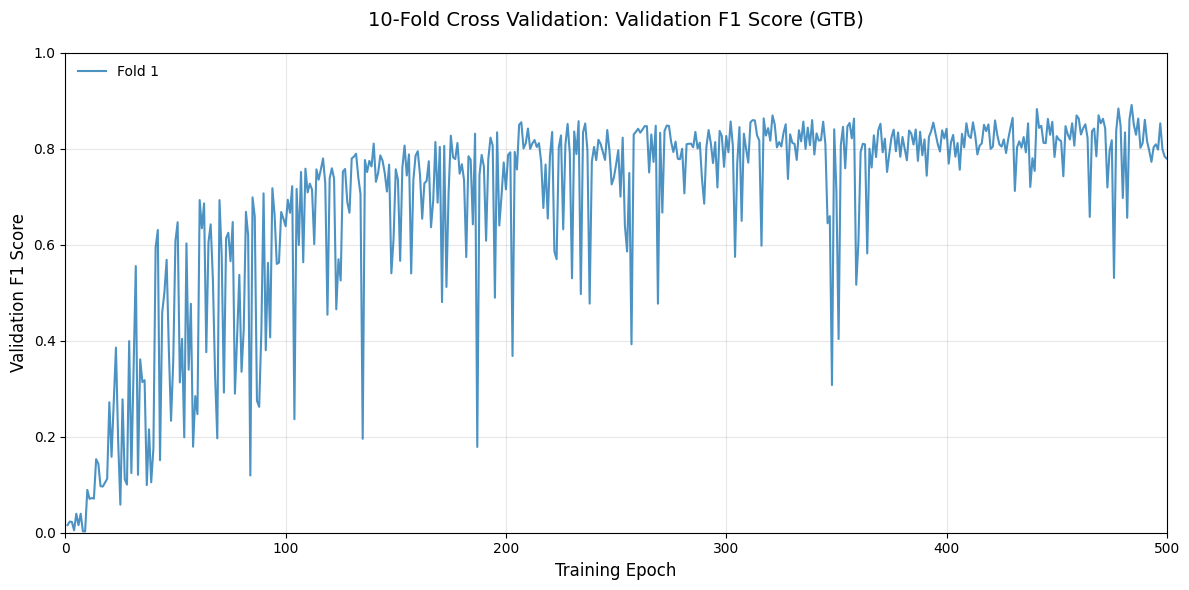

In [11]:
import os
import pandas as pd

data_path = "./model_param_alldata/"
base_name = "GTmining_6_6_GTB_fold"

validation_data = []
for fold in range(1, 11):
    folder_name = f"{base_name}{fold}"
    tsv_filename = os.path.join(data_path, folder_name, 'validation_log.csv')
    df = pd.read_csv(tsv_filename)
    validation_data.append(df['validation_f1_score'].to_list())

import matplotlib.pyplot as plt
import numpy as np

# ===================== 1. 替换为你的真实数据 =====================
# 示例：10个嵌套列表，每个子列表是某一折的validation_f1_score（长度为训练轮次）
# 你需将下面的示例数据替换成自己的10折F1分数列表
val_f1_scores = validation_data

# ===================== 2. 配置绘图样式（10种不同颜色+线型+标记） =====================
# 10种区分度高的颜色（matplotlib tab10配色，适配10折）
colors = plt.cm.tab10(np.linspace(0, 1, 10))
# 10种不同线型（确保视觉区分）
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
# 10种不同标记（增强区分度）
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '+', 'x']

# ===================== 3. 绘制折线图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 解决中文显示（无中文可删）
plt.figure(figsize=(12, 6))  # 画布大小：宽12，高6

# 循环绘制每折的F1分数折线
for fold_idx in range(0, 1):
    # 获取当前折的F1分数
    f1 = val_f1_scores[fold_idx]
    # 训练轮次（x轴，长度与F1分数一致）
    epochs = range(1, len(f1) + 1)
    
    # 绘制折线：颜色+线型+标记+标签
    plt.plot(
        epochs, f1,
        color=colors[fold_idx],
        linestyle=linestyles[fold_idx],
        # marker=markers[fold_idx],
        label=f'Fold {fold_idx + 1}',  # 图例标签：Fold 1 ~ Fold 10
        linewidth=1.5,  # 线条宽度
        alpha=0.8,
        # markersize=6    # 标记大小
    )

# ===================== 4. 图表美化与标注 =====================
# plt.title('10-Fold Cross Validation: Validation F1 Score (GTA)', fontsize=14, pad=20)
plt.title('10-Fold Cross Validation: Validation F1 Score (GTB)', fontsize=14, pad=20)
plt.xlabel('Training Epoch', fontsize=12)
plt.ylabel('Validation F1 Score', fontsize=12)
plt.ylim(0, 1)  # y轴范围
plt.xlim(0, 500)  # x轴范围
# plt.ylim(0, 0.8)  # y轴范围
# plt.xlim(0, 1000)  # x轴范围
plt.grid(True, alpha=0.3)  # 网格线（增强可读性）
plt.legend(loc='upper left', ncol=2, edgecolor='white')  # 图例：右下位置，2列展示（避免拥挤）
plt.tight_layout()  # 自动调整布局（防止标签重叠）

# ===================== 5. 保存/显示图表 =====================
# plt.savefig('./result/10fold_val_f1_score_GTB.png', dpi=1200, bbox_inches='tight')  # 保存为高清PNG
# plt.savefig('./result/10fold_val_f1_score_GTB.svg', bbox_inches='tight')  # 保存为SVG
plt.show()  # 显示图表


## 模型epoch逐条预测

### 拿validation数据，选取前十的epoch

In [4]:
import os
import pandas as pd

best_20_epochs = {}
fold_type = 'GTA'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'

for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    df.sort_values(by='validation_f1_score', ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)

    epochs_20 = df.loc[0:19, 'epoch'].values.tolist()
    best_20_epochs[fold] = epochs_20
    print(f"Fold type {fold_type}, Fold: {fold}, Top 20 Epochs: {epochs_20}")


Fold type GTA, Fold: 1, Top 20 Epochs: [672, 698, 723, 931, 883, 638, 940, 925, 600, 718, 839, 834, 885, 853, 970, 508, 917, 816, 868, 928]
Fold type GTA, Fold: 2, Top 20 Epochs: [820, 883, 764, 822, 994, 851, 733, 746, 770, 732, 699, 972, 752, 782, 966, 868, 801, 876, 997, 795]
Fold type GTA, Fold: 3, Top 20 Epochs: [974, 973, 879, 849, 838, 996, 930, 893, 850, 884, 929, 863, 854, 825, 871, 933, 960, 891, 631, 875]
Fold type GTA, Fold: 4, Top 20 Epochs: [570, 895, 999, 754, 728, 690, 940, 814, 794, 804, 964, 741, 942, 929, 777, 909, 904, 778, 914, 632]
Fold type GTA, Fold: 5, Top 20 Epochs: [721, 788, 717, 910, 451, 494, 791, 437, 787, 388, 573, 392, 907, 946, 633, 620, 840, 601, 969, 570]
Fold type GTA, Fold: 6, Top 20 Epochs: [823, 950, 951, 947, 915, 949, 948, 706, 825, 953, 786, 833, 965, 824, 909, 918, 912, 957, 954, 961]
Fold type GTA, Fold: 7, Top 20 Epochs: [964, 885, 929, 975, 915, 862, 965, 953, 978, 875, 930, 982, 908, 934, 704, 922, 903, 824, 935, 983]
Fold type GTA, Fold:

### 评估validation数据集中的数据标签，并临时保存下来

In [5]:
import argparse
import textwrap
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import pandas as pd

import os
import pandas as pd

In [6]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )

def prepare_data_one(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=1,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )




In [7]:
fold_num = 1


# ========================================
data_path = "./model_param_alldata/"
base_name = f"GTmining_6_6_{family_fold_type}_fold"
folder_name = f"{base_name}{fold_num}"
# ========================================

print("{:=^100}".format(f'fold num is : {fold_num}, family type is : {family_fold_type}'))

print("{:=^100}".format('prog_args'))
prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data_one(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data_one(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_validation)+ len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'


===============================fold num is : 1, family type is : GTA================================
=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 9
the max num node is 537
number of graphs is 11489
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 53


In [8]:
# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()



model init finished
MODEL::::::: diffpool


In [7]:
print("Fold_num is {}{:=^100}".format(fold_num, '开始选择最佳epoch进行验证'))
for top_i in range(0, 20):
    epoch = best_20_epochs[fold_num][top_i]

    begin_time = time.time()
    print("\nEPOCH ###### {} ######".format(epoch))
    if epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch), weights_only=True
            )
        )

    id_card_protein = {}
    # validation test
    with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
        for dd in f.readlines():
            dd = dd.split('\n')[0].split('===')
            id_card_protein[dd[1]] = dd[0]

    id_card_record_list = []
    real_label_record_list = []
    predict_label_record_list = []
    graph_label_dict_reverse = {v: k for k, v in graph_label_dict.items()}

    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(validation_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()

            # 拿标签
            temp = batch_graph
            protein_temp_id_card = ''
            protein_temp_id_card = protein_temp_id_card + "{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][0][0]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][1]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][2]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][3]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][4]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][5]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][0][6]), 5))
            protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][1][0]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][1]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][2]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][3]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][4]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][5]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][1][6]), 5))
            protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][2][0]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][1]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][2]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][3]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][4]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][5]), 5),
                                                                                                                                    round(float(temp.ndata['feat'][2][6]), 5))
            protein_id = id_card_protein[protein_temp_id_card]

            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)

            # 记录id_card_record_list，real_label_record_list，predict_label_record_list
            id_card_record_list.append(protein_id)
            real_label_record_list.append(graph_label_dict_reverse[int(graph_labels.cpu())])
            predict_label_record_list.append(graph_label_dict_reverse[int(indi.cpu())])

            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()

            # print(f"Protein name is : {protein_id}, and its activate is {int(indi.cpu())}.")
            
    elapsed_time = time.time() - begin_time
    print("epoch {:.4f} with epoch time {:.4f} s".format(epoch, elapsed_time))
    result = correct_label / len(validation_dataloader.dataset)

    # 记录预测的label数据文件
    storage_label_file = prog_args.save_dir + "/" + prog_args.dataset + f"/validation_pred_labels_epoch_{epoch}_top{top_i}.csv"

    with open(storage_label_file, 'w') as f:
        f.write("ID_Card,Real_Label,Predict_Label\n")
        for id_card, real_label, predict_label in zip(id_card_record_list, real_label_record_list, predict_label_record_list):
            f.write(f"{id_card},{real_label},{predict_label}\n")
    f.close()
    


Fold_num is 2==========================================开始选择最佳epoch进行验证===========================================

EPOCH ###### 820 ######


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


epoch 820.0000 with epoch time 68.2437 s

EPOCH ###### 883 ######
epoch 883.0000 with epoch time 67.9794 s

EPOCH ###### 764 ######
epoch 764.0000 with epoch time 68.1338 s

EPOCH ###### 822 ######
epoch 822.0000 with epoch time 67.9739 s

EPOCH ###### 994 ######
epoch 994.0000 with epoch time 68.4180 s

EPOCH ###### 851 ######
epoch 851.0000 with epoch time 67.9992 s

EPOCH ###### 733 ######
epoch 733.0000 with epoch time 68.3600 s

EPOCH ###### 746 ######
epoch 746.0000 with epoch time 68.7898 s

EPOCH ###### 770 ######
epoch 770.0000 with epoch time 68.2058 s

EPOCH ###### 732 ######
epoch 732.0000 with epoch time 68.1694 s

EPOCH ###### 699 ######
epoch 699.0000 with epoch time 69.7996 s

EPOCH ###### 972 ######
epoch 972.0000 with epoch time 69.0332 s

EPOCH ###### 752 ######
epoch 752.0000 with epoch time 68.5955 s

EPOCH ###### 782 ######
epoch 782.0000 with epoch time 68.7326 s

EPOCH ###### 966 ######
epoch 966.0000 with epoch time 68.6036 s

EPOCH ###### 868 ######
epoch 868.

In [ ]:
# 在select_epoch_temp_script.py中进行长时间的预测，睡觉去了

# 都使用fold1的数据进行评估，保证数据的一致性，方便进行选择。

### 开始评估

In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
from dataclasses import dataclass  # 用于定义轻量级数据结构类
from typing import List, Dict        # 类型提示支持
from tqdm import tqdm               # 进度条显示
from multiprocessing import Pool    # 多进程并行计算
import os                           # 操作系统相关功能（如获取 CPU 核心数）

# ==================== 数据结构定义 ====================
@dataclass
class EpochRecord:
    """
    表示单个模型在某个训练 epoch 的记录。
    
    属性:
        epoch (int): 当前训练轮次编号。
        predictions (np.ndarray): 该 epoch 对所有样本的预测结果（整数类别标签）。
    """
    epoch: int
    predictions: np.ndarray

@dataclass
class ModelRecord:
    """
    表示一个模型的多个 epoch 记录（仅保留表现较好的若干 epoch）。
    
    属性:
        model_id (int): 模型唯一标识符。
        epochs (List[EpochRecord]): 该模型保存的若干 epoch 记录列表（按 F1 降序排列）。
    """
    model_id: int
    epochs: List[EpochRecord]

# ==================== 全局函数====================
def read_training_data(fold_type='GTB'):
    """
    读取模型的训练数据，直接从文件中读取评估好的validation数据和排名。
    不包含F1 Score信息。
    
    参数:
        fold_type (str): 数据集类型，'GTA' 或 'GTB'。
    
    返回:
        models (List[ModelRecord]): 所有模型的记录列表。
        true_labels (np.ndarray): 真实标签数组（长度为 n_samples）。
    """
    # 映射关系
    if fold_type == 'GTA':
        graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                            'UDP-Gal': 3, 'UDP-GalNAc': 4,
                            'UDP-Xyl': 5, 'GDP-Man': 6,
                            'dTDP-Rha': 7, 'Other': 8}
    elif fold_type == 'GTB':
        graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                            'UDP-Gal': 3, 'UDP-GalNAc': 4,
                            'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                            'dTDP-Rha': 8, 'Other': 9}

    # 真实标签
    if fold_type == 'GTA':
        df_real = pd.read_csv(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold1/validation_pred_labels_epoch_672_top0.csv')
    elif fold_type == 'GTB':
        df_real = pd.read_csv(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold1/validation_pred_labels_epoch_483_top0.csv')
    true_labels = df_real['Real_Label'].map(graph_label_dict).to_numpy()

    # 模型验证指标
    models = []
    # 使用 tqdm 显示模型生成进度
    n_models = 10
    if fold_type == 'GTA':
        n_epochs_per_model = 100
    elif fold_type == 'GTB':
        n_epochs_per_model = 50
    # n_epochs_per_model = 10
    with tqdm(total=n_models, desc="生成模型数据", unit="模型") as pbar_model:
        for model_id in range(n_models):
            epochs = []
            epoch2top_dict = {x: None for x in range(n_epochs_per_model)}
            files = os.listdir(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold{model_id+1}/')
            for file in files:
                if file.startswith('validation_pred_labels_epoch_') and file.endswith('.csv'):
                    parts = file.split('_')
                    epoch_num = int(parts[4])
                    top_num = int(parts[5][3:-4])  # 去掉 'top' 和 '.csv'
                    # print(f"模型 {model_id+1} 读取到文件: {file}, epoch: {epoch_num}, top: {top_num}")
                    if top_num in epoch2top_dict.keys():
                        epoch2top_dict[top_num] = epoch_num
            assert all(v is not None for v in epoch2top_dict.values()), f"模型 {model_id+1} 的某些 epoch 缺少 top 信息"
            # print(f"模型 {model_id+1} 的 epoch 到 top 映射: {epoch2top_dict}")

            for top in range(n_epochs_per_model):
                df_epoch = pd.read_csv(f'./model_param_alldata/GTmining_6_6_{fold_type}_fold{model_id+1}/validation_pred_labels_epoch_{epoch2top_dict[top]}_top{top}.csv')
                predictions = df_epoch['Predict_Label'].map(graph_label_dict).to_numpy()
                epochs.append(EpochRecord(epoch=epoch2top_dict[top], predictions=predictions))
            models.append(ModelRecord(model_id=model_id, epochs=epochs))
            pbar_model.update(1)  # 更新进度条

    return models, true_labels

def enhanced_selection(models, max_iterations=1000, restarts=3):
    """
    增强版选择策略：多次随机重启 + 局部搜索，避免陷入局部最优。
    
    参数:
        models: 所有模型数据。
        max_iterations: 每次局部搜索的最大迭代数。
        restarts: 重启次数。
    
    返回:
        全局最优组合及其评分。
    """
    best_combination = None
    best_composite_score = -1
    best_scores = None

    with tqdm(total=restarts, desc="重启优化过程", unit="次重启") as pbar_restart:
        for restart in range(restarts):
            # 随机初始化：每个模型从前 5 个 epoch 中随机选一个
            initial_indices = []
            for model in models:
                initial_idx = np.random.randint(min(5, len(model.epochs)))
                initial_indices.append(initial_idx)
            current_combination = [models[i].epochs[initial_indices[i]] for i in range(10)]
            # print(f"\n重启 {restart+1}/{restarts}，初始组合 epoch: {[x.epoch for x in current_combination]}")

            # 执行局部搜索
            current_combination, current_scores = local_search(
                current_combination, models, max_iterations
            )
            # print(f"重启 {restart+1} 完成，组合综合评分: {[x.epoch for x in current_combination]}")

            # 计算当前组合的综合得分
            current_composite = (
                current_scores['comprehensive_score']
            )

            # 更新全局最优
            if current_composite > best_composite_score:
                best_composite_score = current_composite
                best_combination = current_combination.copy()
                best_scores = current_scores.copy()

            pbar_restart.update(1)
            pbar_restart.set_postfix({"全局最优分": f"{best_composite_score:.4f}"})

    return best_combination, best_scores

def local_search(initial_combination, models, max_iterations=200, max_total_evaluations=5000):
    """
    局部搜索算法：在初始组合附近搜索更优解。
    
    策略:
        - 每次迭代尝试微调每个模型的 epoch（±2 范围内）。
        - 使用多进程并行评估所有候选。
        - 一旦找到改进解，立即接受并重置迭代计数器（类似爬山法）。
        - 限制总评估次数防止超时。
    
    参数:
        initial_combination (List[EpochRecord]): 初始组合。
        models (List[ModelRecord]): 所有模型数据。
        max_iterations (int): 最大无改进迭代次数。
        max_total_evaluations (int): 最大总候选评估次数。
    
    返回:
        best_combination, best_scores
    """
    current_combination = initial_combination.copy()
    best_combination = current_combination.copy()

    # 初始评分
    current_scores = evaluate_epoch_combination(current_combination)
    best_scores = current_scores.copy()

    current_composite = current_scores['comprehensive_score']
    best_composite_score = current_composite

    # 记录已尝试过的 (model_idx, epoch_idx) 组合，避免重复评估
    tried_set = set()

    total_evaluations = 0
    with tqdm(total=max_iterations, desc="局部搜索迭代", unit="次", leave=False) as pbar_iter:
        iteration = 0
        while iteration < max_iterations and total_evaluations < max_total_evaluations:
            iteration += 1
            candidates = []

            # 为每个模型生成邻域候选（±2 个 epoch 索引）
            for model_idx in range(10):
                # 找到当前组合中该模型对应的 epoch 在其 epochs 列表中的索引
                current_epoch = current_combination[model_idx]
                current_idx = None
                for idx, e in enumerate(models[model_idx].epochs):
                    if e.epoch == current_epoch.epoch:
                        current_idx = idx
                        break
                if current_idx is None:
                    continue  # 未找到（理论上不应发生）

                # 尝试前后 2 个位置
                for delta in range(-2, 3):
                    new_idx = current_idx + delta
                    if 0 <= new_idx < len(models[model_idx].epochs) and new_idx != current_idx:
                        key = (model_idx, new_idx)
                        if key not in tried_set:
                            candidates.append((model_idx, new_idx))
                            # tried_set.add(key)  # 预标记为已尝试

            if not candidates:
                # print('=========================无新候选')
                break  # 无新候选

            total_evaluations += len(candidates)
            if total_evaluations > max_total_evaluations:
                # print('============================超出上限')
                break

            # 多进程并行评估所有候选
            n_workers = min(len(candidates), os.cpu_count() or 4)
            with Pool(processes=n_workers, initializer=_init_worker, initargs=(models, current_combination)) as pool:
                results = pool.map(_evaluate_candidate_mp, candidates)

            # 寻找最佳改进（贪心）
            best_result = None
            for res in results:
                temp_composite, temp_scores, temp_comb, model_idx, new_idx = res
                if temp_composite > current_composite:
                    if best_result is None or temp_composite > best_result[0]:
                        best_result = (temp_composite, temp_scores, temp_comb, model_idx, new_idx)

            # 如果找到改进，更新当前状态
            if best_result:
                temp_composite, temp_scores, temp_comb, model_idx, new_idx = best_result
                current_combination = temp_comb
                current_scores = temp_scores
                current_composite = temp_composite
                if temp_composite > best_composite_score:
                    best_combination = temp_comb.copy()
                    best_scores = temp_scores.copy()
                    best_composite_score = temp_composite
                # print('找到了更好的状态，更新参数，目前迭代次数：', iteration, temp_composite, best_composite_score)
                # print('找到了更好的状态，更新参数，目前迭代次数：', iteration)
                iteration = 0  # 重置迭代计数器（继续探索）

            pbar_iter.update(1)
            # print('===最终迭代次数：', iteration)
            pbar_iter.set_postfix({"最优综合分": f"{best_composite_score:.4f}"})

    return best_combination, best_scores

def evaluate_epoch_combination(epoch_combination):
    """
    评估一组 epoch（每个模型选一个 epoch）组成的组合的一致性。
    
    参数:
        epoch_combination (List[EpochRecord]): 长度为 n_models 的列表，每个元素是一个 epoch 记录。
    
    返回:
        scores (Dict[str, float]): 包含多种一致性指标的字典。
    """
    predictions_list = [epoch.predictions for epoch in epoch_combination]
    return calculate_consistency_scores(predictions_list)


def calculate_consistency_scores(predictions_list):
    """
    基于多个模型的预测结果，计算多种一致性评分。
    
    参数:
        predictions_list (List[np.ndarray]): 每个元素是某个模型对所有样本的预测（形状: [n_samples]）。
    
    返回:
        scores (Dict[str, float]): 包含以下指标：
            - overall_agreement_rate: 所有模型完全一致的样本比例。
            - mean_variance: 预测值的方差均值（越小越一致）。
            - variance_std: 方差的标准差。
            - mean_mode_dominance: 主导类别的优势程度（众数频次 / 次高频次）。
            - fleiss_kappa: Fleiss' Kappa 一致性系数（衡量多评分者一致性）。
            - comprehensive_score: 加权综合评分。
    """
    predictions_matrix = np.array(predictions_list).T  # 形状: [n_samples, n_models]

    scores = {}

    # 1. 完全一致率：所有模型预测相同的比例
    sample_agreements = np.all(predictions_matrix == predictions_matrix[:, 0:1], axis=1)
    scores['overall_agreement_rate'] = np.mean(sample_agreements)

    # 2. 预测方差（数值型，适用于类别编码为整数的情况）
    sample_variances = np.var(predictions_matrix, axis=1)
    scores['mean_variance'] = np.mean(sample_variances)
    scores['variance_std'] = np.std(sample_variances)

    # 3. 众数优势度：衡量每个样本上最常见预测的“统治力”
    mode_dominances = []
    for i in range(predictions_matrix.shape[0]):
        values, counts = np.unique(predictions_matrix[i], return_counts=True)
        if len(counts) > 1:
            sorted_counts = np.sort(counts)[::-1]  # 降序
            dominance = sorted_counts[0] / sorted_counts[1]  # 主导类 vs 第二类
        else:
            dominance = 1.0  # 全部一致
        mode_dominances.append(dominance)
    scores['mean_mode_dominance'] = np.mean(mode_dominances)

    # 4. Fleiss' Kappa（多评分者一致性指标）
    n_samples, n_models = predictions_matrix.shape
    max_class = int(np.max(predictions_matrix))
    # 构建 one-hot-like 矩阵：kappa_matrix[i, c] = 1 表示第 i 个样本被某个模型预测为类别 c
    kappa_matrix = np.zeros((n_samples, max_class + 1))
    for i in range(n_samples):
        for j in range(n_models):
            kappa_matrix[i, int(predictions_matrix[i, j])] = 1

    # 观察到的一致性：所有模型都预测同一类的样本比例
    observed_agreement = np.sum(np.sum(kappa_matrix, axis=1) == n_models) / n_samples

    # 期望一致性（基于边际分布）
    col_sums = np.sum(kappa_matrix, axis=0)  # 每个类别被预测的总次数
    expected_agreement = np.sum(col_sums * (col_sums - 1)) / (n_samples * n_models * (n_models - 1))

    # Fleiss' Kappa 公式
    if (1 - expected_agreement) == 0:
        scores['fleiss_kappa'] = 0.0
    else:
        scores['fleiss_kappa'] = (observed_agreement - expected_agreement) / (1 - expected_agreement)

    # 5. 综合评分（加权平均）
    weights = {
        'overall_agreement_rate': 0.4,
        'mean_mode_dominance': 0.3,
        'fleiss_kappa': 0.3
    }
    scores['comprehensive_score'] = sum(scores[key] * weights[key] for key in weights)

    return scores

_GLOBAL_MODELS = None
_GLOBAL_BASE_COMBINATION = None

def _init_worker(models, base_combination):
    """
    多进程初始化函数：将只读数据赋值给全局变量，避免每次传递大对象。
    """
    global _GLOBAL_MODELS, _GLOBAL_BASE_COMBINATION
    _GLOBAL_MODELS = models
    _GLOBAL_BASE_COMBINATION = base_combination


def _evaluate_candidate_mp(args):
    """
    多进程评估单个候选解（替换某模型的 epoch）。
    
    参数:
        args (tuple): (model_idx, new_idx)
    
    返回:
        tuple: (综合得分, 详细评分, 新组合, model_idx, new_idx)
    """
    model_idx, new_idx = args
    global _GLOBAL_MODELS, _GLOBAL_BASE_COMBINATION

    # 构造新组合：仅替换指定模型的 epoch
    temp_comb = _GLOBAL_BASE_COMBINATION.copy()
    temp_comb[model_idx] = _GLOBAL_MODELS[model_idx].epochs[new_idx]

    # 评估一致性
    temp_scores = evaluate_epoch_combination(temp_comb)

    # 综合目标函数：70% 一致性 + 30% 平均 F1
    temp_composite = temp_scores['comprehensive_score']

    return temp_composite, temp_scores, temp_comb, model_idx, new_idx

In [12]:
print("=== 读取验证数据 ===")
models, true_labels = read_training_data(fold_type='GTA')

# 1. 数据概览
print("\n=== 数据概览 ===")
for model in models:
    print(f"\n模型 {model.model_id}:", end="")
    print(f"  - 共有 {len(model.epochs)} 个最优epoch", end="")
    print(f"  - 最佳epoch: Epoch {model.epochs[0].epoch}", end="")

# 2. 组合优化
print("\n=== 开始组合优化 ===")
best_combination, best_scores = enhanced_selection(models, max_iterations=10, restarts=100)



=== 读取验证数据 ===


生成模型数据: 100%|██████████| 10/10 [00:01<00:00,  5.27模型/s]



=== 数据概览 ===

模型 0:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 672
模型 1:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 820
模型 2:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 974
模型 3:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 570
模型 4:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 721
模型 5:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 823
模型 6:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 964
模型 7:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 882
模型 8:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 482
模型 9:  - 共有 100 个最优epoch  - 最佳epoch: Epoch 426
=== 开始组合优化 ===


重启优化过程: 100%|██████████| 100/100 [16:30<00:00,  9.91s/次重启, 全局最优分=1.8678]


In [13]:
# 3. 最终结果
print("\n=== 优化完成 ===")
final_composite = best_scores['comprehensive_score']
print(f"最终综合评分: {final_composite:.4f}")
print(f"各模型选择的 epoch: {[e.epoch for e in best_combination]}")

# 4. 展示结果
print("\n=== 最优组合结果 ===")
print(f"组合综合评分: {best_scores['comprehensive_score']:.4f}")
print(f"一致性评分: {best_scores['comprehensive_score']:.4f}")

# 5. 详细展示每个epoch的选择
print("\n=== 各模型选择的epoch ===")
for i, epoch in enumerate(best_combination):
    print(f"模型 {i}: Epoch {epoch.epoch:3d}")

# 6. 一致性详细分析
print("\n=== 一致性详细分析 ===")
predictions_matrix = np.array([e.predictions for e in best_combination]).T

class_distributions = []
for class_id in range(10):
    counts = []
    for epoch in best_combination:
        counts.append(np.sum(epoch.predictions == class_id))
    class_distributions.append({
        'class': class_id,
        'counts': counts,
        'mean': np.mean(counts),
        'std': np.std(counts)
    })

df_dist = pd.DataFrame(class_distributions)
print("\n各类别在10个模型中的预测数量分布:")
print(df_dist.round(1))

# 7. 与真实标签对比
print("\n=== 与真实标签对比 ===")
majority_votes = []
for i in range(len(true_labels)):
    votes = predictions_matrix[i]
    counts = np.bincount(votes.astype(int))
    majority_votes.append(np.argmax(counts))

majority_votes = np.array(majority_votes)
accuracy = np.mean(majority_votes == true_labels)
print(f"多数投票准确率: {accuracy:.2%}")

model_accuracies = []
# 模型准确率进度条
with tqdm(total=len(best_combination), desc="计算模型准确率", unit="模型", leave=False) as pbar_acc:
    for i, epoch in enumerate(best_combination):
        acc = np.mean(epoch.predictions == true_labels)
        model_accuracies.append(acc)
        print(f"模型 {i}: 准确率 = {acc:.2%}")
        pbar_acc.update(1)

print(f"\n平均准确率: {np.mean(model_accuracies):.2%}")

# GTA
# [931, 822, 879, 814, 451, 949, 929, 430, 364, 353] 1.8678 94.20% 94.15% 1.6905

# GTB
# [477, 360, 295, 381, 382, 418, 436, 350, 377, 206] 1.3761 98.36% 97.75% 1.3682
# [477, 360, 295, 381, 382, 418, 332, 350, 345, 206] 1.3808 98.41%
# [477, 360, 295, 381, 406, 418, 332, 350, 377, 143] 1.3826 98.44%
# [477, 360, 295, 381, 382, 418, 332, 350, 377, 206] 1.3823 98.38%


=== 优化完成 ===
最终综合评分: 1.8678
各模型选择的 epoch: [931, 822, 879, 814, 451, 949, 929, 430, 364, 353]

=== 最优组合结果 ===
组合综合评分: 1.8678
一致性评分: 1.8678

=== 各模型选择的epoch ===
模型 0: Epoch 931
模型 1: Epoch 822
模型 2: Epoch 879
模型 3: Epoch 814
模型 4: Epoch 451
模型 5: Epoch 949
模型 6: Epoch 929
模型 7: Epoch 430
模型 8: Epoch 364
模型 9: Epoch 353

=== 一致性详细分析 ===

各类别在10个模型中的预测数量分布:
   class                                             counts    mean    std
0      0  [977, 542, 1026, 1283, 1021, 1057, 1098, 1007,...  1009.8  175.5
1      1  [436, 668, 436, 298, 440, 506, 495, 413, 485, ...   455.5   91.5
2      2          [55, 50, 69, 62, 50, 54, 51, 74, 100, 51]    61.6   15.1
3      3  [141, 223, 174, 160, 201, 190, 210, 184, 154, ...   182.0   24.3
4      4          [49, 71, 57, 48, 47, 56, 69, 126, 60, 64]    64.7   21.9
5      5             [34, 21, 0, 21, 21, 28, 9, 21, 18, 24]    19.7    9.0
6      6  [370, 308, 299, 262, 285, 345, 288, 212, 350, ...   301.3   43.7
7      7             [13, 33, 19, 9, 6, 10,

模型 0: 准确率 = 72.63%
模型 1: 准确率 = 69.84%
模型 2: 准确率 = 93.14%
模型 3: 准确率 = 82.02%
模型 4: 准确率 = 93.53%
模型 5: 准确率 = 86.71%
模型 6: 准确率 = 84.90%
模型 7: 准确率 = 86.14%
模型 8: 准确率 = 84.28%
模型 9: 准确率 = 93.62%

平均准确率: 84.68%


In [ ]:
# 评估手动选取的epoch，看看评分是多少
GTA_best_epoch = {
        1: 367, 2: 764, 3: 631, 4: 570,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    }
GTA_best_epoch = {
        1: 508, 2: 764, 3: 631, 4: 570,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    } # 1的367找不到，所以调试了一下
# GTB_best_epoch = {
#         1: 206, 2: 245, 3: 152, 4: 141,
#         5: 225, 6: 137, 7: 119, 8: 216,
#         9: 205, 10: 143
#     }
# GTB_best_epoch = {
#         1: 206, 2: 245, 3: 152, 4: 211,
#         5: 225, 6: 137, 7: 119, 8: 216,
#         9: 205, 10: 143
#     } # 4的141找不到，所以调试了一下

# GTA
# [931, 822, 879, 814, 451, 949, 929, 430, 364, 353] 1.8678 94.20% 94.15% 1.6905

# GTB
# [477, 360, 295, 381, 382, 418, 436, 350, 377, 206] 1.3761 98.36%
# [477, 360, 295, 381, 382, 418, 332, 350, 345, 206] 1.3808 98.41%
# [477, 360, 295, 381, 406, 418, 332, 350, 377, 143] 1.3826 98.44% 97.75% 1.3682
# [477, 360, 295, 381, 382, 418, 332, 350, 377, 206] 1.3823 98.38%



current_combination = []
for model in models:
    epoch_to_use = GTA_best_epoch[model.model_id + 1]
    try:
        current_combination.append(next(epoch for epoch in model.epochs if epoch.epoch == epoch_to_use))
    except StopIteration:
        raise ValueError(f"模型 {model.model_id + 1} 中未找到指定的 epoch {epoch_to_use}")
    
predictions_list = [epoch.predictions for epoch in current_combination]

print(calculate_consistency_scores(predictions_list)['comprehensive_score'])
# 1.6905815261738775

# 7. 与真实标签对比
predictions_matrix = np.array([e.predictions for e in current_combination]).T
print("\n=== 与真实标签对比 ===")
majority_votes = []
for i in range(len(true_labels)):
    votes = predictions_matrix[i]
    counts = np.bincount(votes.astype(int))
    majority_votes.append(np.argmax(counts))

majority_votes = np.array(majority_votes)
accuracy = np.mean(majority_votes == true_labels)
print(f"多数投票准确率: {accuracy:.2%}")



1.6905815261738775

=== 与真实标签对比 ===
多数投票准确率: 94.15%


# 绘制图像

## ROC曲线

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTA'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    if fold == 3:
        continue
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")


Fold type GTA, Fold: 1, Max Val F1 Score: 0.5815390849141838, Best Epoch: 672
Fold type GTA, Fold: 2, Max Val F1 Score: 0.4229043659012874, Best Epoch: 820
Fold type GTA, Fold: 4, Max Val F1 Score: 0.6384374482577936, Best Epoch: 594
Fold type GTA, Fold: 5, Max Val F1 Score: 0.5866380949693626, Best Epoch: 721
Fold type GTA, Fold: 6, Max Val F1 Score: 0.5635060755964714, Best Epoch: 823
Fold type GTA, Fold: 7, Max Val F1 Score: 0.5929194283186159, Best Epoch: 964
Fold type GTA, Fold: 8, Max Val F1 Score: 0.6744514234160764, Best Epoch: 548
Fold type GTA, Fold: 9, Max Val F1 Score: 0.6452862481235005, Best Epoch: 482
Fold type GTA, Fold: 10, Max Val F1 Score: 0.598277855359986, Best Epoch: 426


In [3]:
if fold_type == 'GTA':
    # best_epochs = {
    #     1: 367, 2: 764, 3: 631, 4: 570,
    #     5: 451, 6: 473, 7: 704, 8: 292,
    #     9: 364, 10: 353
    # }
    best_epochs = {
        1: 367, 2: 764, 3: 631, 4: 594,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    }
elif fold_type == 'GTB':
    best_epochs = {
        1: 206, 2: 245, 3: 152, 4: 141,
        5: 225, 6: 137, 7: 119, 8: 216,
        9: 205, 10: 143
    }


best_epochs

{1: 367,
 2: 764,
 3: 631,
 4: 594,
 5: 451,
 6: 473,
 7: 704,
 8: 292,
 9: 364,
 10: 353}

In [4]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [5]:
fold_num = 1

param_folder = f'{log_save_folder}{fold_num}'
print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()









from sklearn.metrics import auc, roc_curve

roc_history_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}

for fold_num in range(1, 11):
    param_folder = f'{log_save_folder}{fold_num}'
    print("{:=^100}".format('prog_args'))
    # 尝试
    if fold_type == 'GTA':
        prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
    elif fold_type == 'GTB':
        prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

    print(textwrap.fill(str(prog_args), width=100))

    print("{:=^100}".format('加载数据'))
    dataset_test = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
    test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

    epoch = best_epochs[fold_num]

    begin_time = time.time()
    print("\nEPOCH ###### {} ######".format(epoch))
    if epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch), weights_only=True
            )
        )

    id_card_protein = {}
    # validation test
    with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
        for dd in f.readlines():
            dd = dd.split('\n')[0].split('===')
            id_card_protein[dd[1]] = dd[0]

    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        val_pred_proba = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(test_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            ypred_proba = torch.nn.Softmax(dim=1)(ypred)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            val_pred_proba = torch.cat((val_pred_proba, ypred_proba), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
    
    if fold_type == 'GTA':
        num_classes = 9
    elif fold_type == 'GTB':
        num_classes = 10
    for plot_flag in range(num_classes):
        y_test_temp = []
        for i in range(len(val_label_indi)):
            if int(val_label_indi[i]) == plot_flag:
                y_test_temp.append(1)
            else:
                y_test_temp.append(0)
        t_fpr, t_tpr, thre = roc_curve(y_test_temp, val_pred_proba.cpu()[:, plot_flag])
        roc_history_dict[plot_flag].append([t_fpr, t_tpr, thre])
        

    # break

=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 9
the max num node is 537
number of graphs is 9231
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 53
model init finished
MODEL::::::: diffpool
=============================================prog_args=================

/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold2', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================

EPOCH ###### 764 ######
=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold3', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode=

In [6]:
# 保存roc_hostory
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history.npy"
np.save(os.path.join('./result/', npy_filename), roc_history_dict)


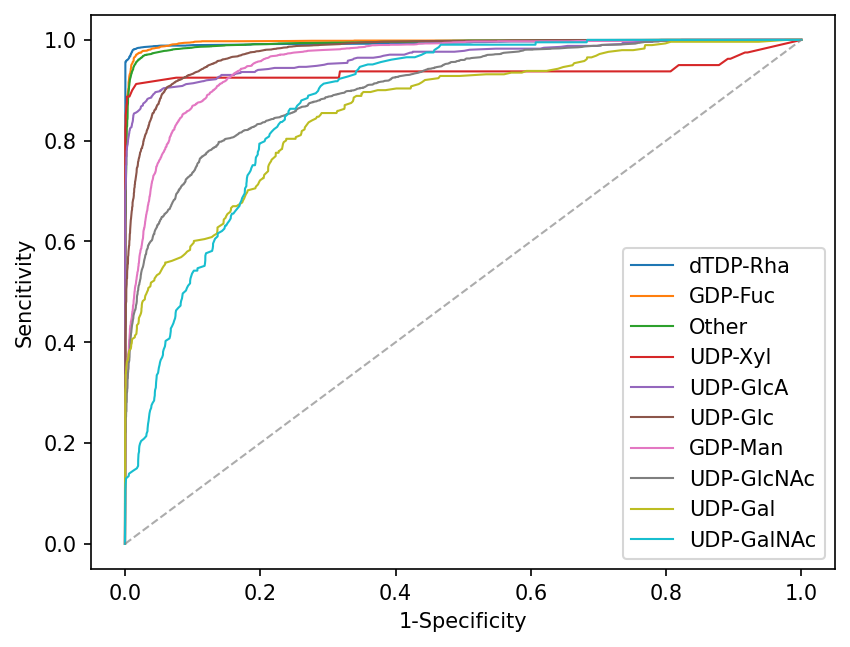

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import auc, roc_curve

fold_type = 'GTB'

if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history.npy"
roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

if fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{fold_type}'. Valid options are 'GTA' and 'GTB'.")
graph_label_dict = {v: k for k, v in graph_label_dict.items()}

plt.figure(dpi=150)
if fold_type == 'GTA':
    plot_flags = [7,1,4,0,3,6,2,8,5]
elif fold_type == 'GTB':
    plot_flags = [8,7,9,5,2,0,6,1,3,4]
for plot_flag in plot_flags:
    roc_history = roc_history_dict[plot_flag]
    auc_history, value, fpr, tpr = [], [], [], []
    for t_fpr, t_tpr, thre in roc_history:
        #计算AUC
        auc_score = auc(t_fpr, t_tpr)
        auc_history.append(auc_score)
        fpr.append([float(i) for i in t_fpr])
        value.extend([float(i) for i in t_fpr])
        tpr.append([float(i) for i in t_tpr])

    mean_fpr, min_fpr, max_fpr = [],[],[]
    mean_tpr, min_tpr, max_tpr= [],[],[]
    #这个是为了对曲线进行插值，因为每个曲线的样本不一样，所以获取到的fpr和tpr也不一样长度，
    #所以需要进行插值
    #插值的原理是，获取所有fpr的值，然后将每个交叉验证的roc都插值成和fpr的值一样多的长度。
    #插值并不会改变每个roc曲线的形状，这个可以放心使用
    unique = np.unique(np.array(value).flatten())
    #对fpr和tpr进行插值
    for l in range(len(fpr)):
        tpr[l] = np.interp(unique, fpr[l], tpr[l], 0, 1)
        fpr[l] = np.interp(unique, fpr[l], fpr[l], 0, 1)
        #将每个交叉验证的ROC都画出来
        # plt.plot(fpr[l], tpr[l])

    fpr = np.array(fpr)
    tpr = np.array(tpr)
    #求fpr和tpr的极大极小，获取每个实验所能触及的最大指标范围
    min_fpr = np.min(fpr, axis=0)
    max_fpr = np.max(fpr, axis=0)
    min_tpr = np.min(tpr, axis=0)
    max_tpr = np.max(tpr, axis=0)
    #获取均值，为了得到交叉验证的平均曲线
    mean_tpr = np.mean(tpr, axis=0)
    mean_fpr = np.mean(fpr, axis=0)
    mean_tpr[0] = 0

    
    # plt.title(graph_label_dict[plot_flag])
    plt.xlabel('1-Specificity')
    plt.ylabel('Sencitivity')
    #画平均曲线
    plt.plot(mean_fpr, mean_tpr, marker=None,
            linewidth=1,
            alpha=1, label=graph_label_dict[plot_flag])#markeredgecolor='b',
    
plt.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10), linestyle='--',c='grey', linewidth=1, alpha=0.65)

plt.legend(loc='lower right')
#展示图象
if fold_type == 'GTA':
    # output_path = f'./result/20251226-roc-GTA.png'
    # plt.savefig(output_path, dpi=1200)
    # output_path = f'./result/20251226-roc-GTA.svg'
    # plt.savefig(output_path, format='svg', dpi=1200)
    plt.show()
elif fold_type == 'GTB':
    # output_path = f'./result/20251226-roc-GTB.png'
    # plt.savefig(output_path, dpi=1200)
    # output_path = f'./result/20251226-roc-GTB.svg'
    # plt.savefig(output_path, format='svg', dpi=1200)
    plt.show()

    # break

## AUC-曲线下面积

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import auc, roc_curve

fold_type = 'GTB'

if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history.npy"
roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

if fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{fold_type}'. Valid options are 'GTA' and 'GTB'.")
graph_label_dict = {v: k for k, v in graph_label_dict.items()}

if fold_type == 'GTA':
    plot_flags = [7,1,4,0,3,6,2,8,5]
elif fold_type == 'GTB':
    plot_flags = [8,7,9,5,2,0,6,1,3,4]


# 假设 roc_history_dict 和 graph_label_dict 已经定义

for plot_flag in plot_flags:
    # 获取当前类别的ROC历史记录
    roc_history = roc_history_dict[plot_flag]
    
    auc_scores = []
    for t_fpr, t_tpr, thre in roc_history:
        # 计算AUC分数
        auc_score = auc(t_fpr, t_tpr)
        auc_scores.append(auc_score)
    
    # 计算并打印平均AUC值
    mean_auc = np.mean(auc_scores)
    print(f"Category {graph_label_dict[plot_flag]}: Mean AUC = {mean_auc:.4f}")

Category dTDP-Rha: Mean AUC = 0.9946
Category GDP-Fuc: Mean AUC = 0.9963
Category Other: Mean AUC = 0.9932
Category UDP-Xyl: Mean AUC = 0.9377
Category UDP-GlcA: Mean AUC = 0.9651
Category UDP-Glc: Mean AUC = 0.9766
Category GDP-Man: Mean AUC = 0.9561
Category UDP-GlcNAc: Mean AUC = 0.9051
Category UDP-Gal: Mean AUC = 0.8613
Category UDP-GalNAc: Mean AUC = 0.8725


## PR-ROC曲线

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTA'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    # if fold == 3:
    #     continue
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")


Fold type GTA, Fold: 1, Max Val F1 Score: 0.5815390849141838, Best Epoch: 672
Fold type GTA, Fold: 2, Max Val F1 Score: 0.4229043659012874, Best Epoch: 820
Fold type GTA, Fold: 3, Max Val F1 Score: 0.6957365060009144, Best Epoch: 974
Fold type GTA, Fold: 4, Max Val F1 Score: 0.6384374482577936, Best Epoch: 594
Fold type GTA, Fold: 5, Max Val F1 Score: 0.5866380949693626, Best Epoch: 721
Fold type GTA, Fold: 6, Max Val F1 Score: 0.5635060755964714, Best Epoch: 823
Fold type GTA, Fold: 7, Max Val F1 Score: 0.5929194283186159, Best Epoch: 964
Fold type GTA, Fold: 8, Max Val F1 Score: 0.617609507505711, Best Epoch: 882
Fold type GTA, Fold: 9, Max Val F1 Score: 0.6452862481235005, Best Epoch: 482
Fold type GTA, Fold: 10, Max Val F1 Score: 0.598277855359986, Best Epoch: 426


In [3]:
if fold_type == 'GTA':
    # best_epochs = {
    #     1: 367, 2: 764, 3: 631, 4: 570,
    #     5: 451, 6: 473, 7: 704, 8: 292,
    #     9: 364, 10: 353
    # }
    best_epochs = {
        1: 367, 2: 764, 3: 631, 4: 594,
        5: 451, 6: 473, 7: 704, 8: 832,
        9: 364, 10: 353
    }
    # best_epochs = {
    #     1: 367, 2: 764, 3: 631, 4: 594,
    #     5: 451, 6: 473, 7: 704, 8: 548,
    #     9: 364, 10: 353
    # }
elif fold_type == 'GTB':
    best_epochs = {
        1: 206, 2: 245, 3: 152, 4: 141,
        5: 225, 6: 137, 7: 119, 8: 216,
        9: 205, 10: 143
    }


best_epochs

{1: 367,
 2: 764,
 3: 631,
 4: 594,
 5: 451,
 6: 473,
 7: 704,
 8: 832,
 9: 364,
 10: 353}

In [4]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [5]:
fold_num = 1

param_folder = f'{log_save_folder}{fold_num}'
print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()



=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 9
the max num node is 537
number of graphs is 9231
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 53
model init finished
MODEL::::::: diffpool


In [6]:
from sklearn.metrics import auc, roc_curve

roc_history_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}

for fold_num in range(1, 11):
    param_folder = f'{log_save_folder}{fold_num}'
    print("{:=^100}".format('prog_args'))
    # 尝试
    if fold_type == 'GTA':
        prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
    elif fold_type == 'GTB':
        prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

    print(textwrap.fill(str(prog_args), width=100))

    print("{:=^100}".format('加载数据'))
    dataset_test = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
    test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

    epoch = best_epochs[fold_num]

    begin_time = time.time()
    print("\nEPOCH ###### {} ######".format(epoch))
    if epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch), weights_only=True
            )
        )

    id_card_protein = {}
    # validation test
    with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
        for dd in f.readlines():
            dd = dd.split('\n')[0].split('===')
            id_card_protein[dd[1]] = dd[0]

    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        val_pred_proba = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(test_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            ypred_proba = torch.nn.Softmax(dim=1)(ypred)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            val_pred_proba = torch.cat((val_pred_proba, ypred_proba), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
    
    if fold_type == 'GTA':
        num_classes = 9
    elif fold_type == 'GTB':
        num_classes = 10

    y_true = val_label_indi.cpu().numpy()
    y_score = val_pred_proba.cpu().numpy()
    for plot_flag in range(num_classes):
        # 构造二分类标签：当前类别=1，其余=0
        y_binary = (y_true == plot_flag).astype(int)
        y_prob = y_score[:, plot_flag]
        # 保存真实标签 + 预测概率（万能数据！ROC/PRC都能用）
        roc_history_dict[plot_flag].append([y_binary, y_prob])
        
    # break

=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================

EPOCH ###### 367 ######


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold2', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================

EPOCH ###### 764 ######
=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold3', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode=

In [7]:
# 保存roc_hostory
if fold_type == 'GTA':
    # npy_filename = "GTmining_6_6_GTA_pr_roc_history_auto.npy"
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
elif fold_type == 'GTB':
    # npy_filename = "GTmining_6_6_GTB_pr_roc_history_auto.npy"
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
np.save(os.path.join('./result/', npy_filename), roc_history_dict)


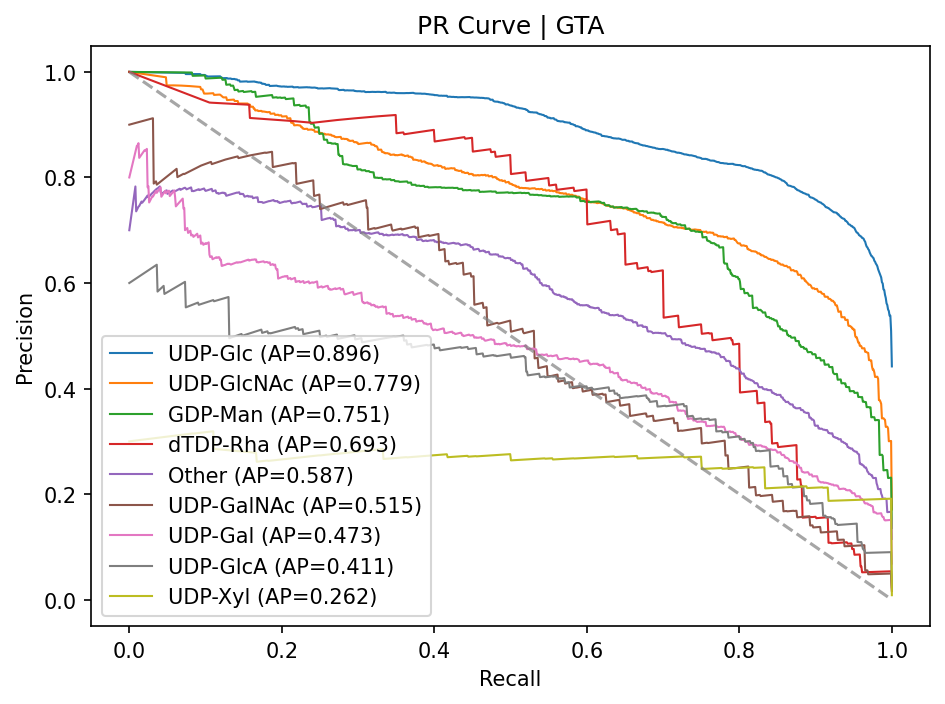

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 核心配置：切换只需改这里 =====================
fold_type = 'GTA'          # GTA / GTB
plot_mode = "ROC"           # ROC = 画ROC曲线 | PR = 画PR曲线
# ==================================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 标签配置
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [7,1,4,0,3,6,2,8,5]
    else:
        plot_flags = [0,1,6,7,8,4,3,2,5]
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [8,7,9,5,2,0,6,1,3,4]
    else:
        plot_flags = [8,9,7,0,2,5,6,1,3,4]

# 统一插值基准
mean_point = np.linspace(0, 1, 1000)

# 绘图
plt.figure(dpi=150)

for flag in plot_flags:
    data_list = roc_history_dict[flag]
    all_y = []

    for y_bin, y_prob in data_list:
        if plot_mode == "ROC":
            # ========== ROC 曲线 ==========
            fpr, tpr, _ = roc_curve(y_bin, y_prob)
            interp_y = np.interp(mean_point, fpr, tpr)
        else:
            # ========== PR 曲线 ==========
            precision, recall, _ = precision_recall_curve(y_bin, y_prob)
            recall = recall[::-1]
            precision = precision[::-1]
            interp_y = np.interp(mean_point, recall, precision)

        all_y.append(interp_y)

    # 计算平均曲线
    mean_y = np.mean(all_y, axis=0)
    score = auc(mean_point, mean_y)
    score_name = "AUC" if plot_mode == "ROC" else "AP"

    # 画图例
    label = f"{graph_label_dict[flag]} ({score_name}={score:.3f})"
    plt.plot(mean_point, mean_y, linewidth=1, label=label)

# ========== 基准线 & 坐标轴 ==========
if plot_mode == "ROC":
    plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
    plt.xlabel('1-Specificity (FPR)')
    plt.ylabel('Sensitivity (TPR)')
    plt.title(f'ROC Curve | {fold_type}')
    plt.legend(loc='lower right')
else:
    plt.plot([0,1], [1,0], '--', color='gray', alpha=0.7)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve | {fold_type}')
    plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 保存（需要就打开）
# plt.savefig(f'./result/{plot_mode}_{fold_type}.png', dpi=1200)
# plt.savefig(f'./result/{plot_mode}_{fold_type}.svg', format='svg')


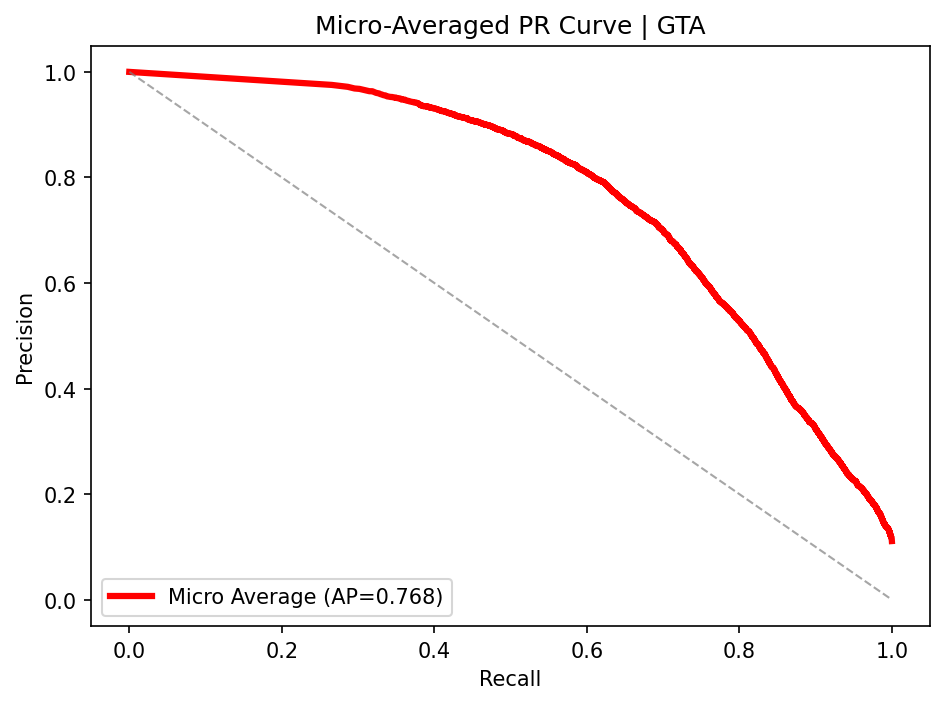


✅ 微平均 Micro PR-AUC = 0.7683


In [12]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTA'  # GTA / GTB
# ==================================================

# 加载数据（你保存的 y_true, y_score）
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    num_classes = 9
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    num_classes = 10

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 标签顺序
if fold_type == 'GTA':
    plot_flags = [7,1,4,0,3,6,2,8,5]
elif fold_type == 'GTB':
    plot_flags = [8,7,9,5,2,0,6,1,3,4]

# ===================== 微平均核心步骤 =====================
# 1. 把所有类别的所有折叠的 y_true 和 y_score 全部合并
all_y_true = []
all_y_score = []

for flag in range(num_classes):
    data_list = roc_history_dict[flag]
    for y_bin, y_prob in data_list:
        all_y_true.extend(y_bin)      # 真实标签（0/1）
        all_y_score.extend(y_prob)    # 预测概率

all_y_true = np.array(all_y_true)
all_y_score = np.array(all_y_score)

# 2. 直接计算 微平均 PR 曲线
precision, recall, _ = precision_recall_curve(all_y_true, all_y_score)
recall = recall[::-1]
precision = precision[::-1]
micro_ap = auc(recall, precision)

# ===================== 绘图 =====================
plt.figure(dpi=150)

# 画 微平均 曲线（红色粗线）
plt.plot(recall, precision, linewidth=3, color='red',
         label=f"Micro Average (AP={micro_ap:.3f})")

# 基准线
plt.plot([0,1], [1,0], '--', color='grey', linewidth=1, alpha=0.7)

# 样式
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Micro-Averaged PR Curve | {fold_type}')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 输出结果
print(f"\n✅ 微平均 Micro PR-AUC = {micro_ap:.4f}")


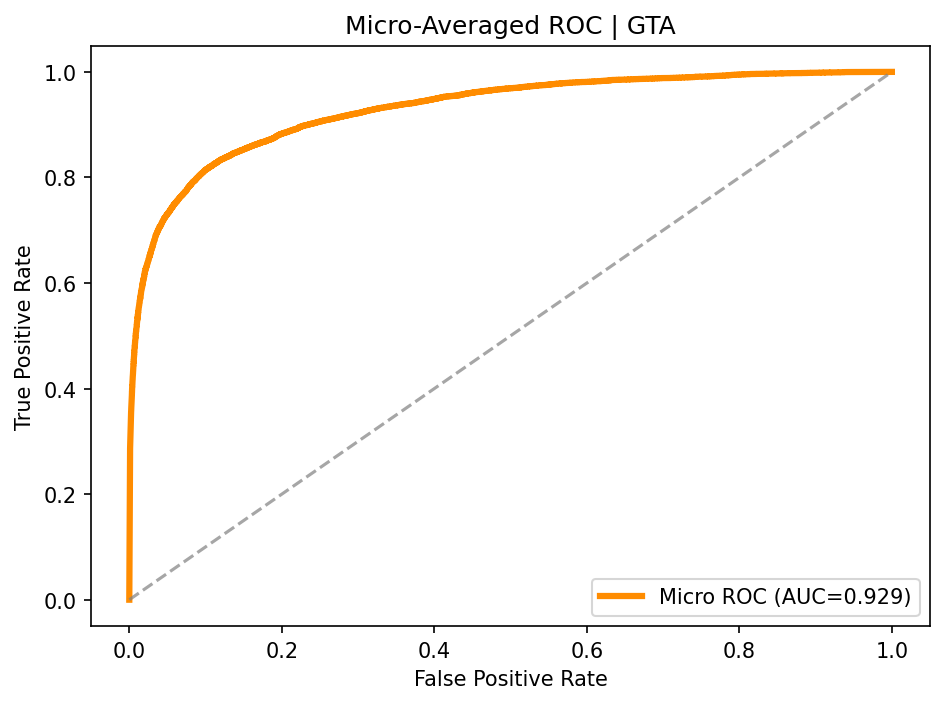

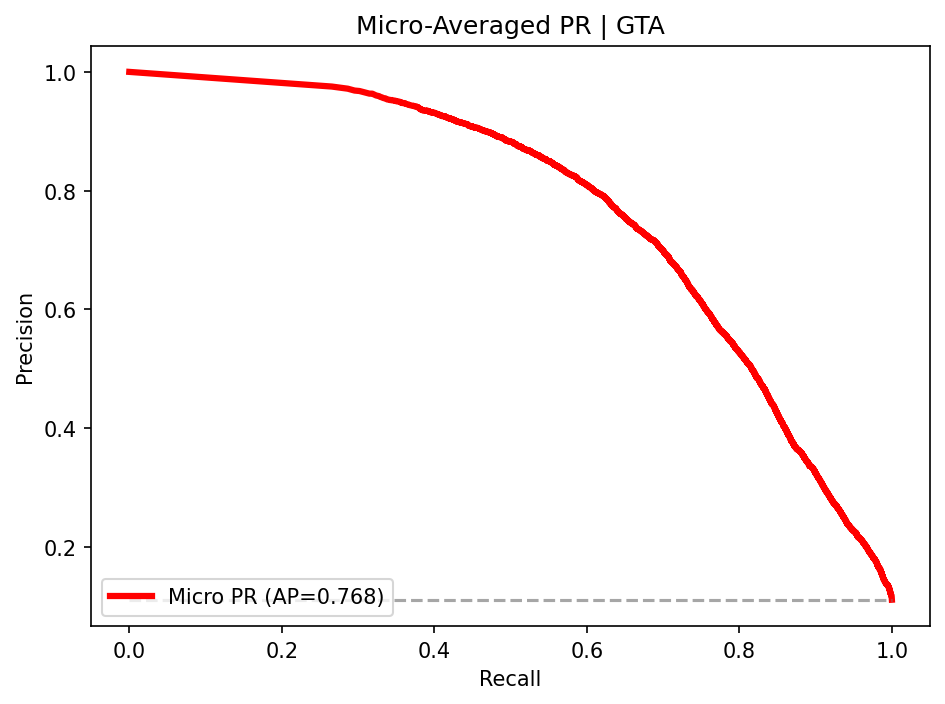


【GTA】 综合指标报告 (All Folds)
  1. Micro ROC-AUC: 0.9291
  2. Micro PR-AUC:  0.7683
  3. F1-Score (Micro): 0.6990
  4. MCC:              0.5986
  5. Accuracy:         0.6990


In [4]:
from sklearn.metrics import (precision_recall_curve, auc, roc_curve,
                             f1_score, matthews_corrcoef, accuracy_score)
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTA'  # GTA / GTB
save_dir = './result_figs'
# ==================================================

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    # npy_filename = "GTmining_6_6_GTA_pr_roc_history_auto.npy"
    num_classes = 9
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    # npy_filename = "GTmining_6_6_GTB_pr_roc_history_auto.npy"
    num_classes = 10

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# ===================== 步骤 1: 收集所有数据 (用于 Micro AUC) =====================
all_y_true_binary = [] # 用于 ROC/PR 曲线的展平二分类标签
all_y_score_binary = [] # 用于 ROC/PR 曲线的展平概率

# 同时，我们需要按 Fold 重组数据，以还原多分类的预测 (用于 F1 和 MCC)
# 先确定有多少个 fold (假设所有类别的 fold 数量一致)
num_folds = len(roc_history_dict[0])

# 初始化列表，用于存放每个 fold 的多分类真实标签和预测标签
all_y_true_multiclass = []
all_y_pred_multiclass = []

# 遍历每个 Fold
for fold_idx in range(num_folds):
    # 先获取该 fold 的样本数量 (以第0类为例)
    y_bin_example, _ = roc_history_dict[0][fold_idx]
    n_samples = len(y_bin_example)
    
    # 初始化该 fold 的矩阵
    y_true_mc_fold = np.zeros(n_samples, dtype=int)
    y_score_mc_fold = np.zeros((n_samples, num_classes))
    
    # 遍历每个类别，填充数据
    for flag in range(num_classes):
        y_bin, y_prob = roc_history_dict[flag][fold_idx]
        
        # 1. 收集用于 Micro AUC 的展平数据
        all_y_true_binary.extend(y_bin)
        all_y_score_binary.extend(y_prob)
        
        # 2. 填充该 fold 的多分类矩阵
        # 确定真实标签：如果这个样本在当前 flag 下是 1，则真实类别就是 flag
        y_true_mc_fold[y_bin == 1] = flag
        # 填充概率矩阵
        y_score_mc_fold[:, flag] = y_prob
    
    # 该 fold 预测完成：通过 argmax 获取预测类别
    y_pred_mc_fold = np.argmax(y_score_mc_fold, axis=1)
    
    # 保存该 fold 的结果
    all_y_true_multiclass.extend(y_true_mc_fold)
    all_y_pred_multiclass.extend(y_pred_mc_fold)

# 转换为 Numpy 数组
all_y_true_binary = np.array(all_y_true_binary)
all_y_score_binary = np.array(all_y_score_binary)
all_y_true_multiclass = np.array(all_y_true_multiclass)
all_y_pred_multiclass = np.array(all_y_pred_multiclass)

# ===================== 步骤 2: 计算各项指标 =====================

# 1. Micro ROC-AUC
fpr_micro, tpr_micro, _ = roc_curve(all_y_true_binary, all_y_score_binary)
micro_roc_auc = auc(fpr_micro, tpr_micro)

# 2. Micro PR-AUC
precision_micro, recall_micro, _ = precision_recall_curve(all_y_true_binary, all_y_score_binary)
recall_micro = recall_micro[::-1]
precision_micro = precision_micro[::-1]
micro_pr_auc = auc(recall_micro, precision_micro)

# 3. F1 Micro (基于多分类预测)
overall_f1_micro = f1_score(all_y_true_multiclass, all_y_pred_multiclass, average='micro')

# 4. MCC (基于多分类预测)
overall_mcc = matthews_corrcoef(all_y_true_multiclass, all_y_pred_multiclass)

# 5. Accuracy
overall_accuracy = accuracy_score(all_y_true_multiclass, all_y_pred_multiclass)

# ===================== 绘图 (ROC) =====================
plt.figure(dpi=150)
plt.plot(fpr_micro, tpr_micro, linewidth=3, color='darkorange',
         label=f"Micro ROC (AUC={micro_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Micro-Averaged ROC | {fold_type}')
plt.legend(loc='lower right')
plt.tight_layout()
# plt.savefig(os.path.join(save_dir, f'Micro_ROC_{fold_type}.png'), dpi=1200, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir, f'Micro_ROC_{fold_type}.svg'), format='svg', bbox_inches='tight')
plt.show()

# ===================== 绘图 (PR) =====================
plt.figure(dpi=150)
plt.plot(recall_micro, precision_micro, linewidth=3, color='red',
         label=f"Micro PR (AP={micro_pr_auc:.3f})")
pos_ratio = np.mean(all_y_true_binary)
plt.plot([0, 1], [pos_ratio, pos_ratio], '--', color='gray', alpha=0.7)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Micro-Averaged PR | {fold_type}')
plt.legend(loc='lower left')
plt.tight_layout()
# plt.savefig(os.path.join(save_dir, f'Micro_PR_{fold_type}.png'), dpi=1200, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir, f'Micro_PR_{fold_type}.svg'), format='svg', bbox_inches='tight')
plt.show()

# ===================== 终端输出 =====================
print("\n" + "="*50)
print(f"【{fold_type}】 综合指标报告 (All Folds)")
print("="*50)
print(f"  1. Micro ROC-AUC: {micro_roc_auc:.4f}")
print(f"  2. Micro PR-AUC:  {micro_pr_auc:.4f}")
print(f"  3. F1-Score (Micro): {overall_f1_micro:.4f}")
print(f"  4. MCC:              {overall_mcc:.4f}")
print(f"  5. Accuracy:         {overall_accuracy:.4f}")
print("="*50)


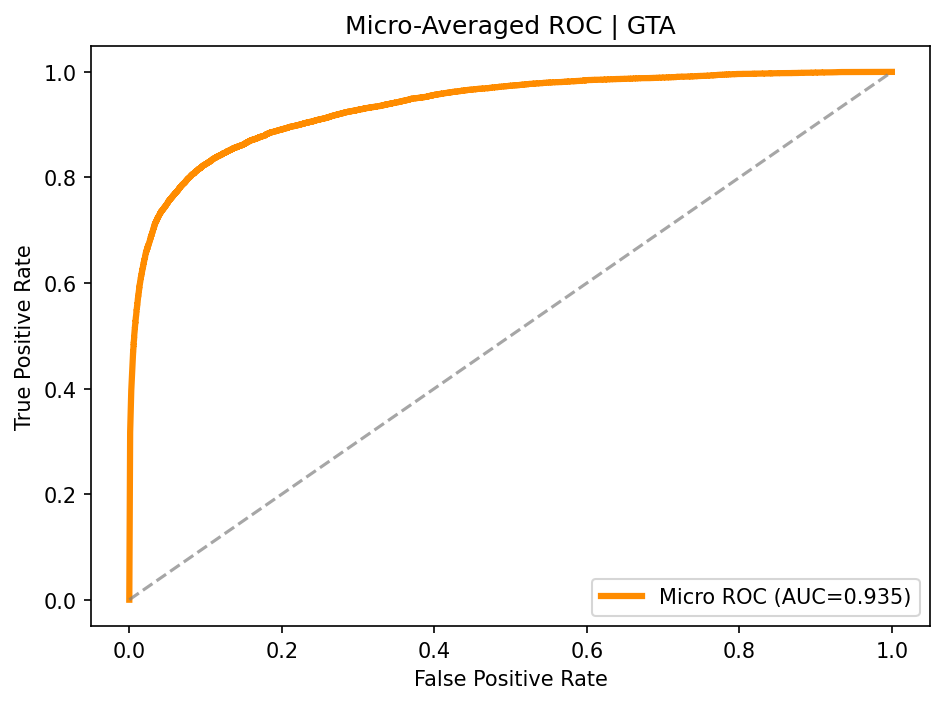

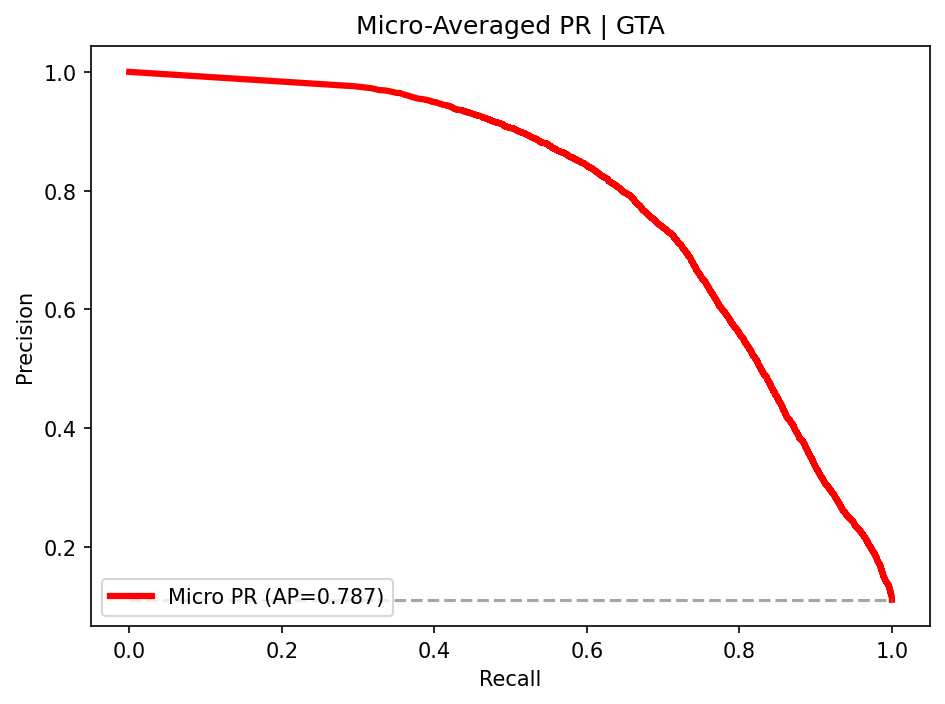


【GTA】 指标汇总报告 (All Folds)

>>> 总体指标 (Overall)
--------------------------------------------------
  1. ROC-AUC (Micro):  0.9349
  2. PR-AUC  (Micro):  0.7866
  3. F1-Score (Micro): 0.7177
  4. MCC:               0.6237
  5. Accuracy:          0.7177
--------------------------------------------------

>>> 分底物详细指标 (Per-substrate)
-----------------------------------------------------------------------------------------------
Substrate       | ROC-AUC    | PR-AUC     | F1-Score   | MCC       
-----------------------------------------------------------------------------------------------
UDP-Glc         | 0.9226     | 0.9196     | 0.8291     | 0.7017    
UDP-GlcNAc      | 0.9472     | 0.7963     | 0.7288     | 0.6729    
UDP-GlcA        | 0.8571     | 0.3875     | 0.4018     | 0.3956    
UDP-Gal         | 0.8853     | 0.4709     | 0.4801     | 0.4428    
UDP-GalNAc      | 0.9268     | 0.5487     | 0.4485     | 0.4623    
UDP-Xyl         | 0.7840     | 0.1805     | 0.3390     | 0.3452    
GDP

In [ ]:
from sklearn.metrics import (precision_recall_curve, auc, roc_curve,
                             f1_score, matthews_corrcoef, accuracy_score)
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTA'  # GTA / GTB
save_dir = './result_figs'
# ==================================================

# --- 新增/修改：参考你的风格，定义详细的标签字典 ---
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    num_classes = 9
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    num_classes = 10
# ----------------------------------------------------

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    # npy_filename = "GTmining_6_6_GTA_pr_roc_history_auto.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    # npy_filename = "GTmining_6_6_GTB_pr_roc_history_auto.npy"

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# ===================== 步骤 1: 收集所有数据 & 重构多分类标签 =====================
all_y_true_binary = [] 
all_y_score_binary = []

num_folds = len(roc_history_dict[0])

all_y_true_multiclass = []
all_y_pred_multiclass = []

for fold_idx in range(num_folds):
    y_bin_example, _ = roc_history_dict[0][fold_idx]
    n_samples = len(y_bin_example)
    
    y_true_mc_fold = np.zeros(n_samples, dtype=int)
    y_score_mc_fold = np.zeros((n_samples, num_classes))
    
    for flag in range(num_classes):
        y_bin, y_prob = roc_history_dict[flag][fold_idx]
        
        all_y_true_binary.extend(y_bin)
        all_y_score_binary.extend(y_prob)
        
        y_true_mc_fold[y_bin == 1] = flag
        y_score_mc_fold[:, flag] = y_prob
    
    y_pred_mc_fold = np.argmax(y_score_mc_fold, axis=1)
    
    all_y_true_multiclass.extend(y_true_mc_fold)
    all_y_pred_multiclass.extend(y_pred_mc_fold)

all_y_true_binary = np.array(all_y_true_binary)
all_y_score_binary = np.array(all_y_score_binary)
all_y_true_multiclass = np.array(all_y_true_multiclass)
all_y_pred_multiclass = np.array(all_y_pred_multiclass)

# ===================== 步骤 2: 计算综合指标 =====================

# 1. Micro ROC-AUC
fpr_micro, tpr_micro, _ = roc_curve(all_y_true_binary, all_y_score_binary)
micro_roc_auc = auc(fpr_micro, tpr_micro)

# 2. Micro PR-AUC
precision_micro, recall_micro, _ = precision_recall_curve(all_y_true_binary, all_y_score_binary)
recall_micro = recall_micro[::-1]
precision_micro = precision_micro[::-1]
micro_pr_auc = auc(recall_micro, precision_micro)

# 3. F1 Micro
overall_f1_micro = f1_score(all_y_true_multiclass, all_y_pred_multiclass, average='micro')

# 4. MCC
overall_mcc = matthews_corrcoef(all_y_true_multiclass, all_y_pred_multiclass)

# 5. Accuracy
overall_accuracy = accuracy_score(all_y_true_multiclass, all_y_pred_multiclass)

# ===================== 步骤 3: 【借鉴参考代码】计算分底物详细指标 =====================
per_substrate_results = []

for flag in range(num_classes):
    # 1. 收集该底物在所有 Fold 中的原始二分类标签和概率 (用于 ROC/PR AUC)
    y_true_substrate_bin = []
    y_score_substrate_prob = []
    
    for fold_idx in range(num_folds):
        y_bin, y_prob = roc_history_dict[flag][fold_idx]
        y_true_substrate_bin.extend(y_bin)
        y_score_substrate_prob.extend(y_prob)
    
    y_true_substrate_bin = np.array(y_true_substrate_bin)
    y_score_substrate_prob = np.array(y_score_substrate_prob)
    
    # 2. 计算 ROC-AUC
    fpr, tpr, _ = roc_curve(y_true_substrate_bin, y_score_substrate_prob)
    roc_auc_val = auc(fpr, tpr)
    
    # 3. 计算 PR-AUC
    precision, recall, _ = precision_recall_curve(y_true_substrate_bin, y_score_substrate_prob)
    pr_auc_val = auc(recall, precision)
    
    # 4. 【关键逻辑】计算 F1 和 MCC (参考你的代码逻辑：基于多分类预测结果)
    # 从全局多分类预测中，提取当前类别的预测结果 (One-vs-Rest)
    y_pred_substrate = (all_y_pred_multiclass == flag).astype(int)
    # 对应的真实标签
    y_true_substrate_mc = (all_y_true_multiclass == flag).astype(int)
    
    f1_val = f1_score(y_true_substrate_mc, y_pred_substrate)
    mcc_val = matthews_corrcoef(y_true_substrate_mc, y_pred_substrate)
    
    # 保存结果
    per_substrate_results.append({
        'name': graph_label_dict[flag],
        'roc_auc': roc_auc_val,
        'pr_auc': pr_auc_val,
        'f1': f1_val,
        'mcc': mcc_val
    })

# ===================== 绘图 (ROC) =====================
plt.figure(dpi=150)
plt.plot(fpr_micro, tpr_micro, linewidth=3, color='darkorange',
         label=f"Micro ROC (AUC={micro_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Micro-Averaged ROC | {fold_type}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ===================== 绘图 (PR) =====================
plt.figure(dpi=150)
plt.plot(recall_micro, precision_micro, linewidth=3, color='red',
         label=f"Micro PR (AP={micro_pr_auc:.3f})")
pos_ratio = np.mean(all_y_true_binary)
plt.plot([0, 1], [pos_ratio, pos_ratio], '--', color='gray', alpha=0.7)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Micro-Averaged PR | {fold_type}')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# ===================== 【借鉴参考代码】终端输出：分底物详细指标 =====================
print("\n" + "="*80)
print(f"【{fold_type}】 指标汇总报告 (All Folds)")
print("="*80)

print("\n>>> 总体指标 (Overall)")
print("-" * 50)
print(f"  1. ROC-AUC (Micro):  {micro_roc_auc:.4f}")
print(f"  2. PR-AUC  (Micro):  {micro_pr_auc:.4f}")
print(f"  3. F1-Score (Micro): {overall_f1_micro:.4f}")
print(f"  4. MCC:               {overall_mcc:.4f}")
print(f"  5. Accuracy:          {overall_accuracy:.4f}")
print("-" * 50)

print("\n>>> 分底物详细指标 (Per-substrate)")
print("-" * 95)
print(f"{'Substrate':<15} | {'ROC-AUC':<10} | {'PR-AUC':<10} | {'F1-Score':<10} | {'MCC':<10}")
print("-" * 95)
for res in per_substrate_results:
    print(f"{res['name']:<15} | "
          f"{res['roc_auc']:<10.4f} | "
          f"{res['pr_auc']:<10.4f} | "
          f"{res['f1']:<10.4f} | "
          f"{res['mcc']:<10.4f}")
print("-" * 95)


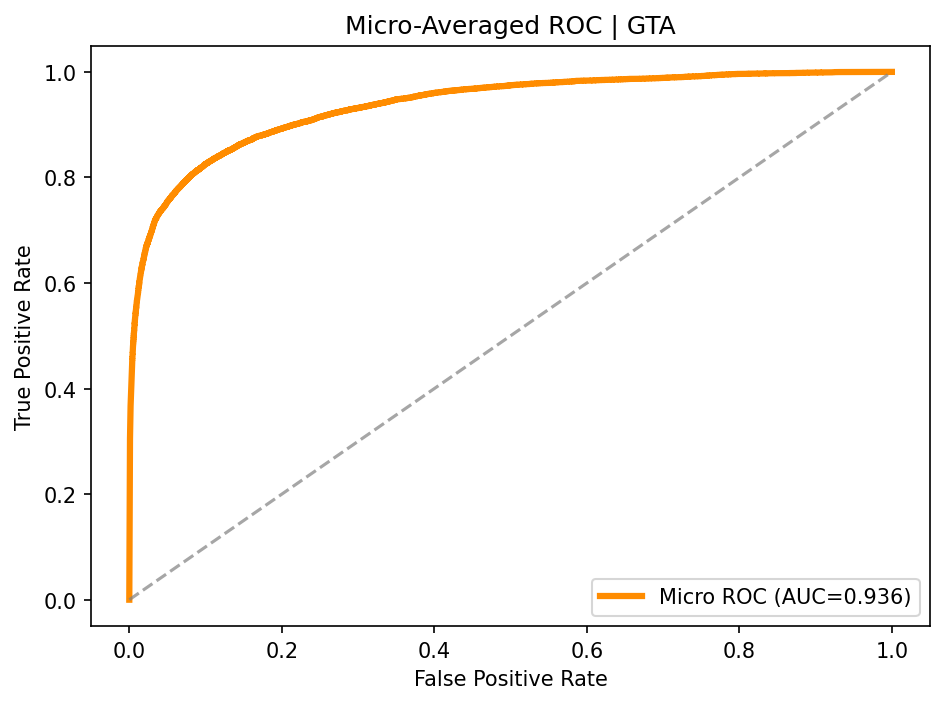

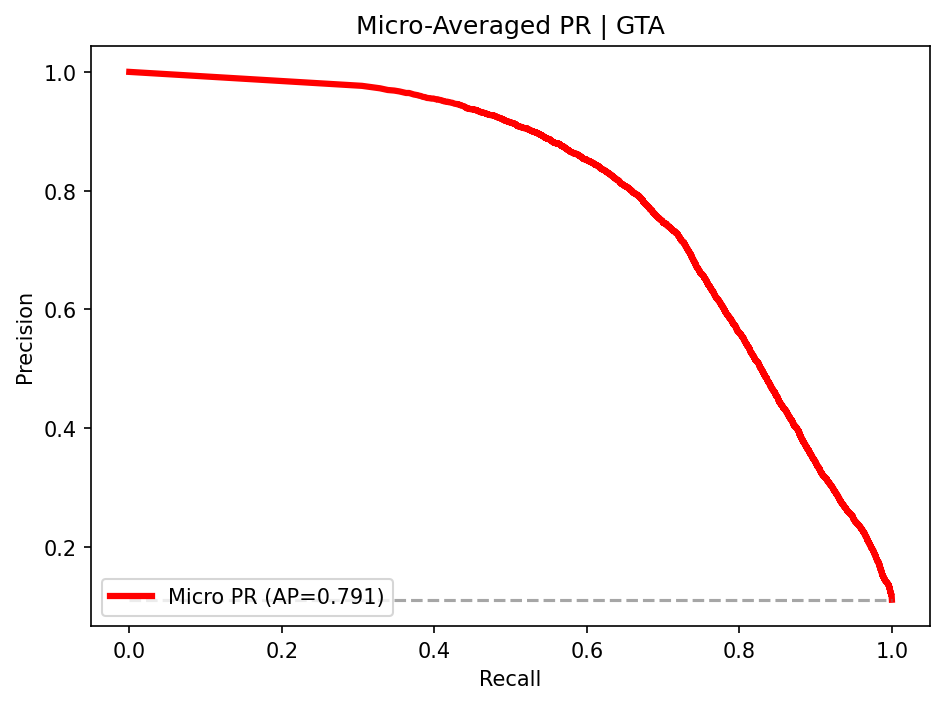


【GTA】 指标汇总报告 (All Folds)

>>> 总体指标 (Overall)
------------------------------------------------------------
  1. ROC-AUC (Micro):  0.9363
  2. PR-AUC  (Micro):  0.7914
  3. Precision (Micro): 0.7217
  4. Recall (Micro):    0.7217
  5. F1-Score (Micro): 0.7217
  6. MCC:               0.6291
  7. Accuracy:          0.7217
------------------------------------------------------------

>>> 分底物详细指标 (Per-substrate)
--------------------------------------------------------------------------------------------------------------------------------------------
Substrate       | ROC-AUC    | PR-AUC     | Precision  | Recall     | F1-Score   | MCC       
--------------------------------------------------------------------------------------------------------------------------------------------
UDP-Glc         | 0.9245     | 0.9211     | 0.8540     | 0.8055     | 0.8291     | 0.7014    
UDP-GlcNAc      | 0.9435     | 0.7988     | 0.6418     | 0.8448     | 0.7294     | 0.6740    
UDP-GlcA        | 0.8410 

In [10]:
from sklearn.metrics import (precision_recall_curve, auc, roc_curve,
                             f1_score, matthews_corrcoef, accuracy_score,
                             precision_score, recall_score)  # <--- 1. 新增导入
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTA'  # GTA / GTB
save_dir = './result_figs'
# ==================================================

# --- 新增/修改：参考你的风格，定义详细的标签字典 ---
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    num_classes = 9
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    num_classes = 10
# ----------------------------------------------------

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    # npy_filename = "GTmining_6_6_GTA_pr_roc_history_auto.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    # npy_filename = "GTmining_6_6_GTB_pr_roc_history_auto.npy"

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# ===================== 步骤 1: 收集所有数据 & 重构多分类标签 =====================
all_y_true_binary = [] 
all_y_score_binary = []

num_folds = len(roc_history_dict[0])

all_y_true_multiclass = []
all_y_pred_multiclass = []

for fold_idx in range(num_folds):
    y_bin_example, _ = roc_history_dict[0][fold_idx]
    n_samples = len(y_bin_example)
    
    y_true_mc_fold = np.zeros(n_samples, dtype=int)
    y_score_mc_fold = np.zeros((n_samples, num_classes))
    
    for flag in range(num_classes):
        y_bin, y_prob = roc_history_dict[flag][fold_idx]
        
        all_y_true_binary.extend(y_bin)
        all_y_score_binary.extend(y_prob)
        
        y_true_mc_fold[y_bin == 1] = flag
        y_score_mc_fold[:, flag] = y_prob
    
    y_pred_mc_fold = np.argmax(y_score_mc_fold, axis=1)
    
    all_y_true_multiclass.extend(y_true_mc_fold)
    all_y_pred_multiclass.extend(y_pred_mc_fold)

all_y_true_binary = np.array(all_y_true_binary)
all_y_score_binary = np.array(all_y_score_binary)
all_y_true_multiclass = np.array(all_y_true_multiclass)
all_y_pred_multiclass = np.array(all_y_pred_multiclass)

# ===================== 步骤 2: 计算综合指标 =====================

# 1. Micro ROC-AUC
fpr_micro, tpr_micro, _ = roc_curve(all_y_true_binary, all_y_score_binary)
micro_roc_auc = auc(fpr_micro, tpr_micro)

# 2. Micro PR-AUC
precision_micro, recall_micro, _ = precision_recall_curve(all_y_true_binary, all_y_score_binary)
recall_micro = recall_micro[::-1]
precision_micro = precision_micro[::-1]
micro_pr_auc = auc(recall_micro, precision_micro)

# 3. Micro Precision, Recall, F1 (新增 Precision 和 Recall)
overall_precision_micro = precision_score(all_y_true_multiclass, all_y_pred_multiclass, average='micro')
overall_recall_micro = recall_score(all_y_true_multiclass, all_y_pred_multiclass, average='micro')
overall_f1_micro = f1_score(all_y_true_multiclass, all_y_pred_multiclass, average='micro')

# 4. MCC
overall_mcc = matthews_corrcoef(all_y_true_multiclass, all_y_pred_multiclass)

# 5. Accuracy
overall_accuracy = accuracy_score(all_y_true_multiclass, all_y_pred_multiclass)

# ===================== 步骤 3: 计算分底物详细指标 =====================
per_substrate_results = []

for flag in range(num_classes):
    # 1. 收集该底物在所有 Fold 中的原始二分类标签和概率 (用于 ROC/PR AUC)
    y_true_substrate_bin = []
    y_score_substrate_prob = []
    
    for fold_idx in range(num_folds):
        y_bin, y_prob = roc_history_dict[flag][fold_idx]
        y_true_substrate_bin.extend(y_bin)
        y_score_substrate_prob.extend(y_prob)
    
    y_true_substrate_bin = np.array(y_true_substrate_bin)
    y_score_substrate_prob = np.array(y_score_substrate_prob)
    
    # 2. 计算 ROC-AUC
    fpr, tpr, _ = roc_curve(y_true_substrate_bin, y_score_substrate_prob)
    roc_auc_val = auc(fpr, tpr)
    
    # 3. 计算 PR-AUC
    precision, recall, _ = precision_recall_curve(y_true_substrate_bin, y_score_substrate_prob)
    pr_auc_val = auc(recall, precision)
    
    # 4. 计算 Precision, Recall, F1 和 MCC
    # 从全局多分类预测中，提取当前类别的预测结果 (One-vs-Rest)
    y_pred_substrate = (all_y_pred_multiclass == flag).astype(int)
    # 对应的真实标签
    y_true_substrate_mc = (all_y_true_multiclass == flag).astype(int)
    
    # <--- 2. 新增计算 Precision 和 Recall，zero_division 防止某类没样本时报错
    precision_val = precision_score(y_true_substrate_mc, y_pred_substrate, zero_division=0)
    recall_val = recall_score(y_true_substrate_mc, y_pred_substrate, zero_division=0)
    f1_val = f1_score(y_true_substrate_mc, y_pred_substrate)
    mcc_val = matthews_corrcoef(y_true_substrate_mc, y_pred_substrate)
    
    # 保存结果
    per_substrate_results.append({
        'name': graph_label_dict[flag],
        'roc_auc': roc_auc_val,
        'pr_auc': pr_auc_val,
        'precision': precision_val, # <--- 新增
        'recall': recall_val,       # <--- 新增
        'f1': f1_val,
        'mcc': mcc_val
    })

# ===================== 绘图 (ROC) =====================
plt.figure(dpi=150)
plt.plot(fpr_micro, tpr_micro, linewidth=3, color='darkorange',
         label=f"Micro ROC (AUC={micro_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Micro-Averaged ROC | {fold_type}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ===================== 绘图 (PR) =====================
plt.figure(dpi=150)
plt.plot(recall_micro, precision_micro, linewidth=3, color='red',
         label=f"Micro PR (AP={micro_pr_auc:.3f})")
pos_ratio = np.mean(all_y_true_binary)
plt.plot([0, 1], [pos_ratio, pos_ratio], '--', color='gray', alpha=0.7)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Micro-Averaged PR | {fold_type}')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# ===================== 终端输出：分底物详细指标 =====================
print("\n" + "="*80)
print(f"【{fold_type}】 指标汇总报告 (All Folds)")
print("="*80)

print("\n>>> 总体指标 (Overall)")
print("-" * 60)
print(f"  1. ROC-AUC (Micro):  {micro_roc_auc:.4f}")
print(f"  2. PR-AUC  (Micro):  {micro_pr_auc:.4f}")
print(f"  3. Precision (Micro): {overall_precision_micro:.4f}") # <--- 新增
print(f"  4. Recall (Micro):    {overall_recall_micro:.4f}")    # <--- 新增
print(f"  5. F1-Score (Micro): {overall_f1_micro:.4f}")
print(f"  6. MCC:               {overall_mcc:.4f}")
print(f"  7. Accuracy:          {overall_accuracy:.4f}")
print("-" * 60)

print("\n>>> 分底物详细指标 (Per-substrate)")
# <--- 3. 调整表格宽度，增加 Precision 和 Recall 列
print("-" * 140) 
print(f"{'Substrate':<15} | {'ROC-AUC':<10} | {'PR-AUC':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'MCC':<10}")
print("-" * 140)
for res in per_substrate_results:
    print(f"{res['name']:<15} | "
          f"{res['roc_auc']:<10.4f} | "
          f"{res['pr_auc']:<10.4f} | "
          f"{res['precision']:<10.4f} | "  # <--- 新增
          f"{res['recall']:<10.4f} | "    # <--- 新增
          f"{res['f1']:<10.4f} | "
          f"{res['mcc']:<10.4f}")
print("-" * 140)


In [8]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTA'  # GTA / GTB
# ==================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    num_classes = 9
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    num_classes = 10

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

num_folds = len(roc_history_dict[0])
fold_pr_aucs = []

# ===================== 循环计算每个 Fold 的 Micro PR-AUC =====================
for fold_idx in range(num_folds):
    y_true_fold = []
    y_score_fold = []
    
    # 收集当前 Fold 中所有类别的数据
    for flag in range(num_classes):
        y_bin, y_prob = roc_history_dict[flag][fold_idx]
        y_true_fold.extend(y_bin)
        y_score_fold.extend(y_prob)
    
    y_true_fold = np.array(y_true_fold)
    y_score_fold = np.array(y_score_fold)
    
    # 计算 PR 曲线及 AUC
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_fold, y_score_fold)
    
    # 修正顺序以确保计算 AUC 时的正确性
    recall_micro = recall_micro[::-1]
    precision_micro = precision_micro[::-1]
    
    current_auc = auc(recall_micro, precision_micro)
    fold_pr_aucs.append(current_auc)

# ===================== 打印结果 =====================
print("\n" + "="*40)
print(f"【{fold_type}】 各 Fold Micro PR-AUC 报告")
print("="*40)
for i, val in enumerate(fold_pr_aucs):
    print(f"  Fold {i+1:2d}:  {val:.4f}")
print("-" * 40)
print(f"  Mean:    {np.mean(fold_pr_aucs):.4f}")
print("="*40 + "\n")



【GTA】 各 Fold Micro PR-AUC 报告
  Fold  1:  0.7708
  Fold  2:  0.7472
  Fold  3:  0.8062
  Fold  4:  0.7751
  Fold  5:  0.8760
  Fold  6:  0.8562
  Fold  7:  0.8003
  Fold  8:  0.6823
  Fold  9:  0.7836
  Fold 10:  0.8044
----------------------------------------
  Mean:    0.7902



In [23]:
from sklearn.metrics import auc, roc_curve

roc_history_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}

fold_num = 8

param_folder = f'{log_save_folder}{fold_num}'
print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)


max_prauc = 0
max_epoch = 0
for epoch in range(prog_args.epoch):
    # print("\nEPOCH ###### {} ######".format(epoch))
# epoch = 271

    begin_time = time.time()
    print("\nEPOCH ###### {} ######".format(epoch))
    if epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch), weights_only=True
            )
        )

    id_card_protein = {}
    # validation test
    with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
        for dd in f.readlines():
            dd = dd.split('\n')[0].split('===')
            id_card_protein[dd[1]] = dd[0]

    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        val_pred_proba = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(test_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            ypred_proba = torch.nn.Softmax(dim=1)(ypred)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            val_pred_proba = torch.cat((val_pred_proba, ypred_proba), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()

    if fold_type == 'GTA':
        num_classes = 9
    elif fold_type == 'GTB':
        num_classes = 10

    y_true = val_label_indi.cpu().numpy()
    y_score = val_pred_proba.cpu().numpy()
    y_true_fold = []
    y_score_fold = []
    for plot_flag in range(num_classes):
        # 构造二分类标签：当前类别=1，其余=0
        y_binary = (y_true == plot_flag).astype(int)
        y_prob = y_score[:, plot_flag]
        # 保存真实标签 + 预测概率（万能数据！ROC/PRC都能用）
        y_true_fold.extend(y_binary)
        y_score_fold.extend(y_prob)


    y_true_fold = np.array(y_true_fold)
    y_score_fold = np.array(y_score_fold)

    # 计算 PR 曲线及 AUC
    precision_micro, recall_micro, _ = precision_recall_curve(y_true_fold, y_score_fold)

    # 修正顺序以确保计算 AUC 时的正确性
    recall_micro = recall_micro[::-1]
    precision_micro = precision_micro[::-1]

    current_auc = auc(recall_micro, precision_micro)

    print(f"Fold {fold_num} Micro PR-AUC: {current_auc:.4f}")
    if current_auc > max_prauc:
        max_prauc = current_auc
        max_epoch = epoch
        print(f"New best PR-AUC: {max_prauc:.4f} at epoch {max_epoch}")
    else:
        print(f"Current PR-AUC: {current_auc:.4f}, Best PR-AUC: {max_prauc:.4f} at epoch {max_epoch}")


    
# break

=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold8', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================

EPOCH ###### 0 ######
Fold 8 Micro PR-AUC: 0.0980
New best PR-AUC: 0.0980 at epoch 0

EPOCH ###### 1 ######
Fold 8 Micro PR-AUC: 0.0788
Current PR-AUC: 0.0788, Best PR-AUC: 0.0980 at epoch 0

EPOCH ###### 2 ######
Fold 8 Micro PR-AUC: 0.0756
Current PR-AUC: 0.0756, Best PR-AUC: 0.0980 at epoch 0

EPOCH ###### 3 ######
Fold 8 Micro PR-AUC: 0.1212
New best PR-AUC: 0.1212 at epoch 3

EPOCH ###### 4 ######
Fold 8 Micro 

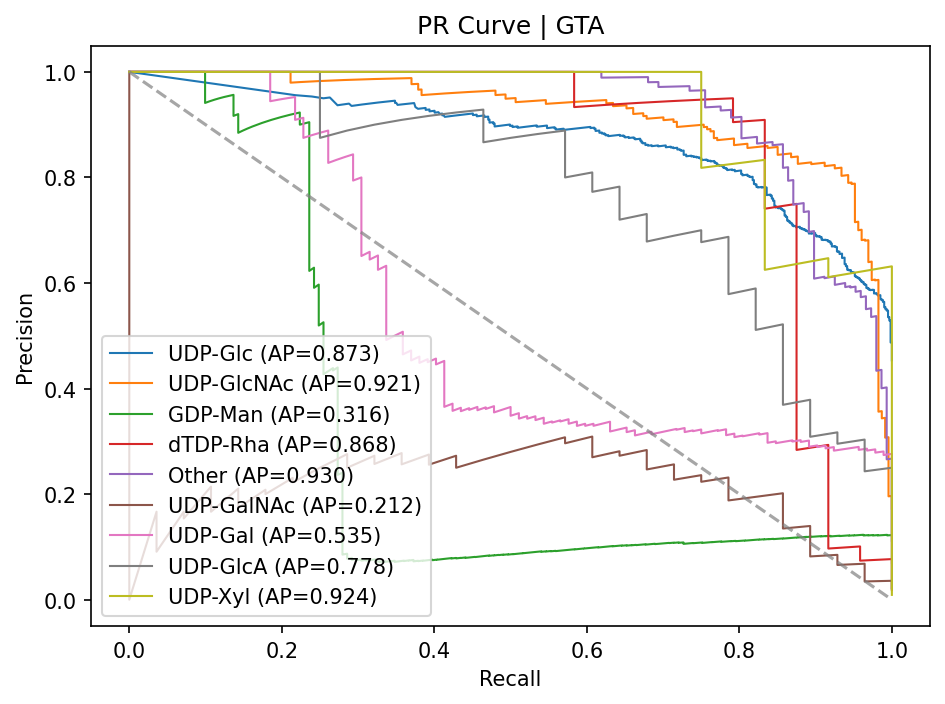

In [2]:
'''
逐个绘制fold的PR曲线
'''

from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 核心配置：切换只需改这里 =====================
fold_type = 'GTA'          # GTA / GTB
plot_mode = "PR"           # ROC = 画ROC曲线 | PR = 画PR曲线
target_fold = 0            # 你想画第几个fold？0=第一个，1=第二个，2=第三个...
# ==================================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 标签配置
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [7,1,4,0,3,6,2,8,5]
    else:
        plot_flags = [0,1,6,7,8,4,3,2,5]
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [8,7,9,5,2,0,6,1,3,4]
    else:
        plot_flags = [8,9,7,0,2,5,6,1,3,4]

# 统一插值基准
mean_point = np.linspace(0, 1, 1000)

# 绘图
plt.figure(dpi=150)

for flag in plot_flags:
    data_list = roc_history_dict[flag]

    y_bin, y_prob = data_list[target_fold]  # 只取第 i 个fold

    if plot_mode == "ROC":
        # ROC 曲线（直接用真实点，不插值）
        fpr, tpr, _ = roc_curve(y_bin, y_prob)
        score = auc(fpr, tpr)
        x_curve, y_curve = fpr, tpr
    else:
        # PR 曲线（直接用真实点，不插值）
        precision, recall, _ = precision_recall_curve(y_bin, y_prob)
        score = auc(recall, precision)
        x_curve, y_curve = recall, precision

    # 分数名称
    score_name = "AUC" if plot_mode == "ROC" else "AP"

    # 画图例
    label = f"{graph_label_dict[flag]} ({score_name}={score:.3f})"
    plt.plot(x_curve, y_curve, linewidth=1, label=label)

# ========== 基准线 & 坐标轴 ==========
if plot_mode == "ROC":
    plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
    plt.xlabel('1-Specificity (FPR)')
    plt.ylabel('Sensitivity (TPR)')
    plt.title(f'ROC Curve | {fold_type}')
    plt.legend(loc='lower right')
else:
    plt.plot([0,1], [1,0], '--', color='gray', alpha=0.7)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve | {fold_type}')
    plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 保存（需要就打开）
# plt.savefig(f'./result/{plot_mode}_{fold_type}.png', dpi=1200)
# plt.savefig(f'./result/{plot_mode}_{fold_type}.svg', format='svg')


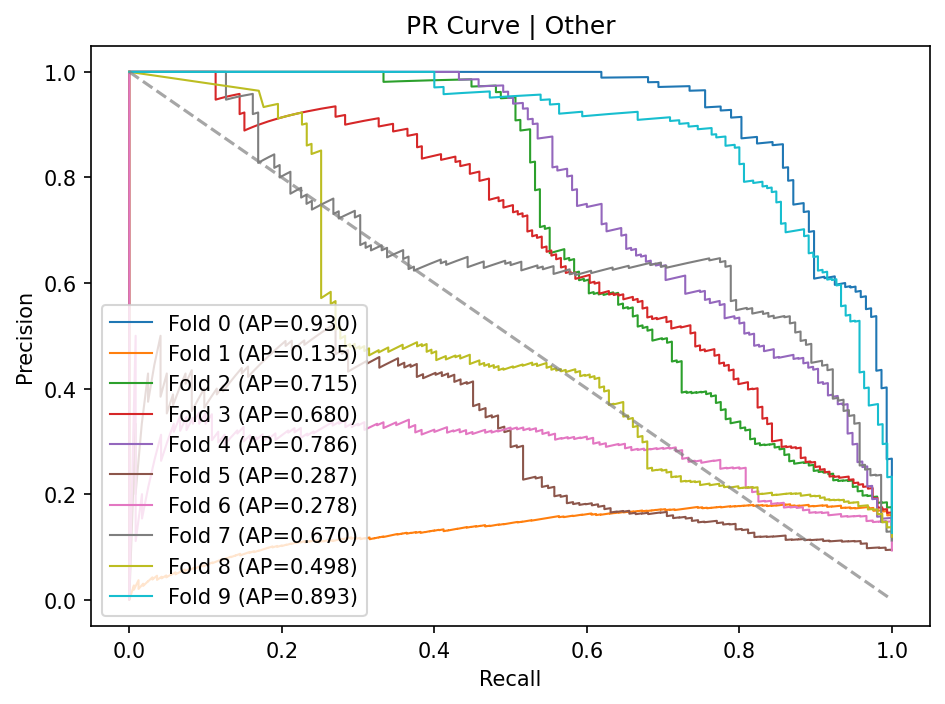

In [12]:
'''
绘制【单个底物】的【所有fold】PR/ROC曲线（10条线）
'''

from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 核心配置：只改这里 =====================
fold_type = 'GTA'          # GTA / GTB
plot_mode = "PR"           # ROC = 画ROC曲线 | PR = 画PR曲线
target_substrate = 8       # 你要画的【底物编号】！！！
# =============================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 底物名称字典
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }

# 拿到这个底物的所有fold数据
substrate_name = graph_label_dict[target_substrate]
data_list = roc_history_dict[target_substrate]

# 绘图
plt.figure(dpi=150)

# 遍历这个底物的【每一个fold】
for fold_idx, (y_bin, y_prob) in enumerate(data_list):
    if plot_mode == "ROC":
        # ROC 曲线
        fpr, tpr, _ = roc_curve(y_bin, y_prob)
        score = auc(fpr, tpr)
        x_curve, y_curve = fpr, tpr
        score_name = "AUC"
    else:
        # PR 曲线
        precision, recall, _ = precision_recall_curve(y_bin, y_prob)
        score = auc(recall, precision)
        x_curve, y_curve = recall, precision
        score_name = "AP"

    # 绘制当前fold的曲线
    plt.plot(x_curve, y_curve, linewidth=1, label=f"Fold {fold_idx} ({score_name}={score:.3f})")

# ========== 基准线 & 坐标轴 ==========
if plot_mode == "ROC":
    plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
    plt.xlabel('1-Specificity (FPR)')
    plt.ylabel('Sensitivity (TPR)')
    plt.title(f'ROC Curve | {substrate_name}')
    plt.legend(loc='lower right')
else:
    plt.plot([0,1], [1,0], '--', color='gray', alpha=0.7)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve | {substrate_name}')
    plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 保存
# plt.savefig(f'./result/{plot_mode}_{fold_type}_{target_substrate}_{substrate_name}.png', dpi=1200)
# plt.savefig(f'./result/{plot_mode}_{fold_type}_{target_substrate}_{substrate_name}.svg', format='svg')


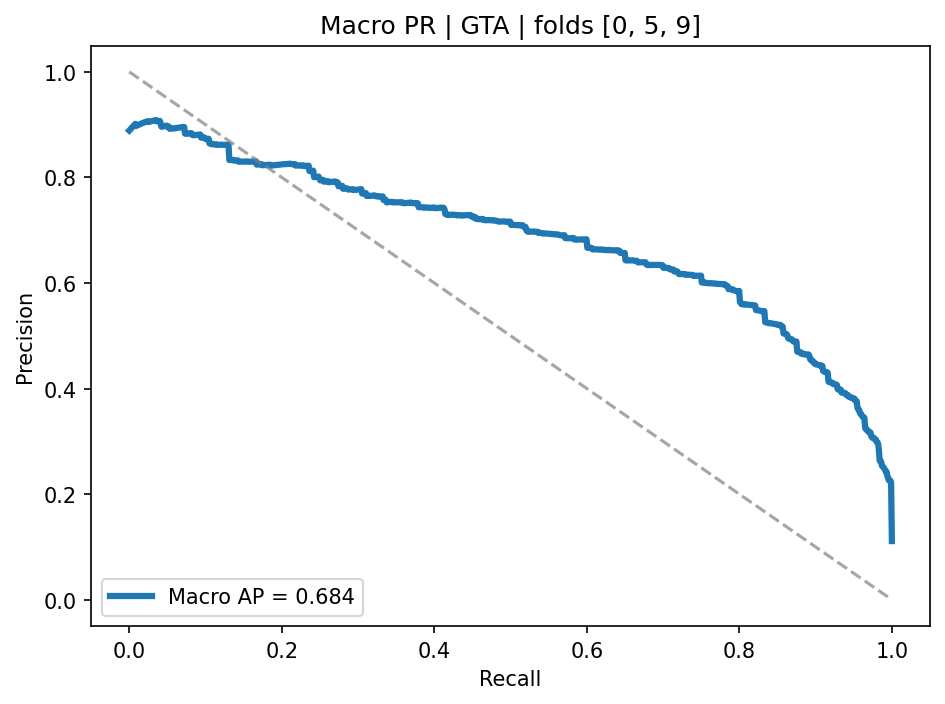

In [11]:
'''
Macro 宏平均 PR / ROC 曲线（所有底物统一平均）
'''

from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTA'
plot_mode = "PR"        # ROC / PR
use_folds = [0,5,9]   # 只使用这3个fold
# =================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    num_classes = 9
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    num_classes = 10

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 插值基准
mean_point = np.linspace(0, 1, 1000)

# 保存所有类别、所有fold的插值曲线
macro_curves = []

# 遍历每个底物（类别）
for class_idx in range(num_classes):
    data_list = roc_history_dict[class_idx]

    # 遍历指定fold
    for fold_idx in use_folds:
        y_bin, y_prob = data_list[fold_idx]

        if plot_mode == "ROC":
            fpr, tpr, _ = roc_curve(y_bin, y_prob)
            interp = np.interp(mean_point, fpr, tpr)
        else:
            precision, recall, _ = precision_recall_curve(y_bin, y_prob)
            recall = recall[::-1]
            precision = precision[::-1]
            interp = np.interp(mean_point, recall, precision)

        macro_curves.append(interp)

# ===================== 宏平均：所有曲线一起平均 =====================
macro_mean = np.mean(macro_curves, axis=0)
macro_score = auc(mean_point, macro_mean)
score_name = "Macro AUC" if plot_mode == "ROC" else "Macro AP"

# 绘图
plt.figure(dpi=150)
plt.plot(mean_point, macro_mean, linewidth=3, label=f"{score_name} = {macro_score:.3f}", color='#1f77b4')

# 基准线
if plot_mode == "ROC":
    plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'Macro ROC | {fold_type} | folds {use_folds}')
    plt.legend(loc='lower right')
else:
    plt.plot([0,1], [1,0], '--', color='gray', alpha=0.7)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Macro PR | {fold_type} | folds {use_folds}')
    plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 保存
# plt.savefig(f'./result/MACRO_{plot_mode}_{fold_type}.png', dpi=1200)


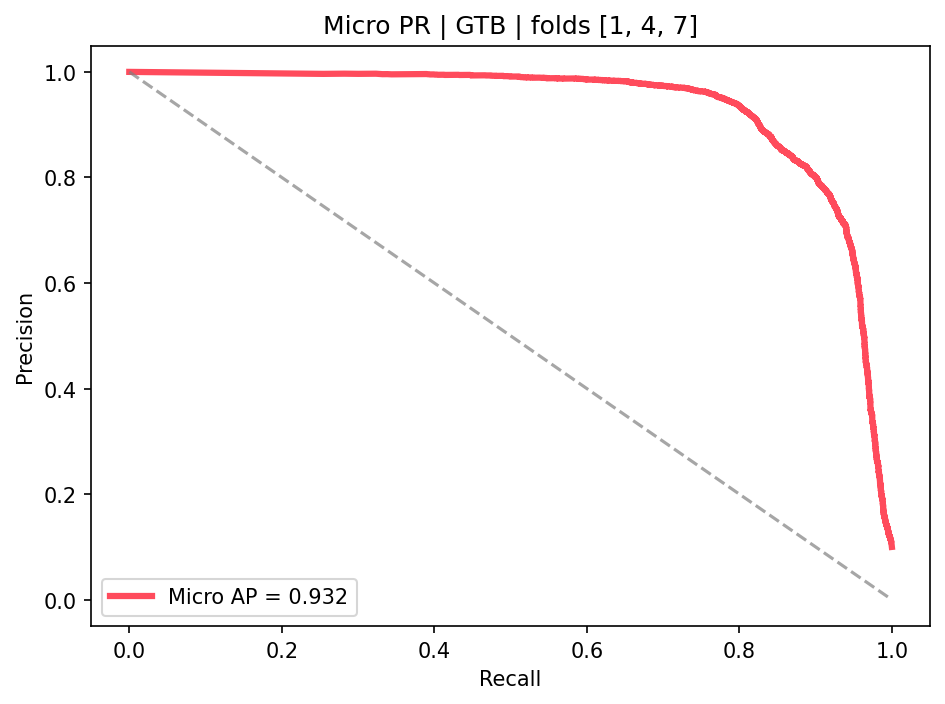

In [4]:
'''
Micro 微平均 PR / ROC 曲线（所有底物合并成一个二分类）
'''

from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTB'
plot_mode = "PR"        # ROC / PR
use_folds = [1,4,7]   # 只使用这3个fold
# =================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    num_classes = 9
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    num_classes = 10

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# ===================== Micro 核心：把所有类别所有fold 拼接在一起 =====================
all_y_true = []
all_y_score = []

# 遍历每个底物
for class_idx in range(num_classes):
    data_list = roc_history_dict[class_idx]
    
    # 遍历指定 fold
    for fold_idx in use_folds:
        y_bin, y_prob = data_list[fold_idx]
        
        # 全部追加到大列表里（Micro 核心操作）
        all_y_true.extend(y_bin)
        all_y_score.extend(y_prob)

# 转 numpy
all_y_true = np.array(all_y_true)
all_y_score = np.array(all_y_score)

# ===================== 计算一条 Micro 曲线 =====================
if plot_mode == "ROC":
    fpr, tpr, _ = roc_curve(all_y_true, all_y_score)
    micro_score = auc(fpr, tpr)
    x, y = fpr, tpr
    score_name = "Micro AUC"
else:
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_score)
    micro_score = auc(recall, precision)
    x, y = recall, precision
    score_name = "Micro AP"

# 绘图
plt.figure(dpi=150)
plt.plot(x, y, linewidth=3, label=f"{score_name} = {micro_score:.3f}", color='#ff4b5c')

# 基准线
if plot_mode == "ROC":
    plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'Micro ROC | {fold_type} | folds {use_folds}')
    plt.legend(loc='lower right')
else:
    plt.plot([0,1], [1,0], '--', color='gray', alpha=0.7)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Micro PR | {fold_type} | folds {use_folds}')
    plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 保存
# plt.savefig(f'./result/MICRO_{plot_mode}_{fold_type}.png', dpi=1200)


In [57]:
'''
搜索 0~9 fold 中所有 3 个组合 → 找出 Micro AP 最高的组合
'''

from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import os
from itertools import combinations  # 自动生成所有3个组合

# ===================== 配置 =====================
fold_type = 'GTA'
# =================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history_manule.npy"
    num_classes = 9
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history_manule.npy"
    num_classes = 10

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# ===================== 搜索所有 3 个 fold 的组合 =====================
best_ap = -1
best_comb = None

# 生成 0~9 中所有 3 个的组合：共 120 种
all_combinations = combinations(range(10), 3)

# 遍历每一种组合
for idx, comb in enumerate(all_combinations):
    use_folds = list(comb)
    
    # Micro 核心：拼接所有类别 + 所有fold的数据
    all_y_true = []
    all_y_score = []
    
    for class_idx in range(num_classes):
        data_list = roc_history_dict[class_idx]
        for fold_idx in use_folds:
            y_bin, y_prob = data_list[fold_idx]
            all_y_true.extend(y_bin)
            all_y_score.extend(y_prob)
    
    # 计算 Micro AP
    all_y_true = np.array(all_y_true)
    all_y_score = np.array(all_y_score)

    precision, recall, _ = precision_recall_curve(all_y_true, all_y_score)
    current_ap = auc(recall, precision)


    # # ===================== MACRO 核心 =====================
    # mean_point = np.linspace(0, 1, 1000)
    # all_interp = []

    # # 遍历每个类别
    # for class_idx in range(num_classes):
    #     data_list = roc_history_dict[class_idx]
        
    #     # 遍历这个组合里的 fold
    #     for fold_idx in use_folds:
    #         y_bin, y_prob = data_list[fold_idx]
            
    #         # 计算 PR 曲线
    #         precision, recall, thresholds = precision_recall_curve(y_bin, y_prob)
    #         recall = recall[::-1]
    #         precision = precision[::-1]
            
    #         # 插值到统一坐标
    #         interp_p = np.interp(mean_point, recall, precision)
    #         all_interp.append(interp_p)

    # # 所有类别 + 所有fold 一起算术平均 = MACRO
    # mean_p = np.mean(all_interp, axis=0)
    # current_ap = auc(mean_point, mean_p)
    
    # # ======================================================


    
    
    
    # 打印进度
    print(f"[{idx+1}/120] 组合 {use_folds} | Micro AP = {current_ap:.4f}")
    
    # 更新最优
    if current_ap > best_ap:
        best_ap = current_ap
        best_comb = use_folds

# ===================== 输出最终结果 =====================
print("\n" + "="*60)
print(f"🎉 最佳 3 个 fold 组合：{best_comb}")
print(f"🔥 最高 Micro AP = {best_ap:.4f}")
print("="*60)


[1/120] 组合 [0, 1, 2] | Micro AP = 0.7706
[2/120] 组合 [0, 1, 3] | Micro AP = 0.7017
[3/120] 组合 [0, 1, 4] | Micro AP = 0.8009
[4/120] 组合 [0, 1, 5] | Micro AP = 0.7923
[5/120] 组合 [0, 1, 6] | Micro AP = 0.7732
[6/120] 组合 [0, 1, 7] | Micro AP = 0.7138
[7/120] 组合 [0, 1, 8] | Micro AP = 0.7665
[8/120] 组合 [0, 1, 9] | Micro AP = 0.7719
[9/120] 组合 [0, 2, 3] | Micro AP = 0.7170
[10/120] 组合 [0, 2, 4] | Micro AP = 0.8179
[11/120] 组合 [0, 2, 5] | Micro AP = 0.8103
[12/120] 组合 [0, 2, 6] | Micro AP = 0.7895
[13/120] 组合 [0, 2, 7] | Micro AP = 0.7308
[14/120] 组合 [0, 2, 8] | Micro AP = 0.7830
[15/120] 组合 [0, 2, 9] | Micro AP = 0.7895
[16/120] 组合 [0, 3, 4] | Micro AP = 0.7550
[17/120] 组合 [0, 3, 5] | Micro AP = 0.7438
[18/120] 组合 [0, 3, 6] | Micro AP = 0.7236
[19/120] 组合 [0, 3, 7] | Micro AP = 0.6480
[20/120] 组合 [0, 3, 8] | Micro AP = 0.7145
[21/120] 组合 [0, 3, 9] | Micro AP = 0.7174
[22/120] 组合 [0, 4, 5] | Micro AP = 0.8360
[23/120] 组合 [0, 4, 6] | Micro AP = 0.8197
[24/120] 组合 [0, 4, 7] | Micro AP = 0.7663
[

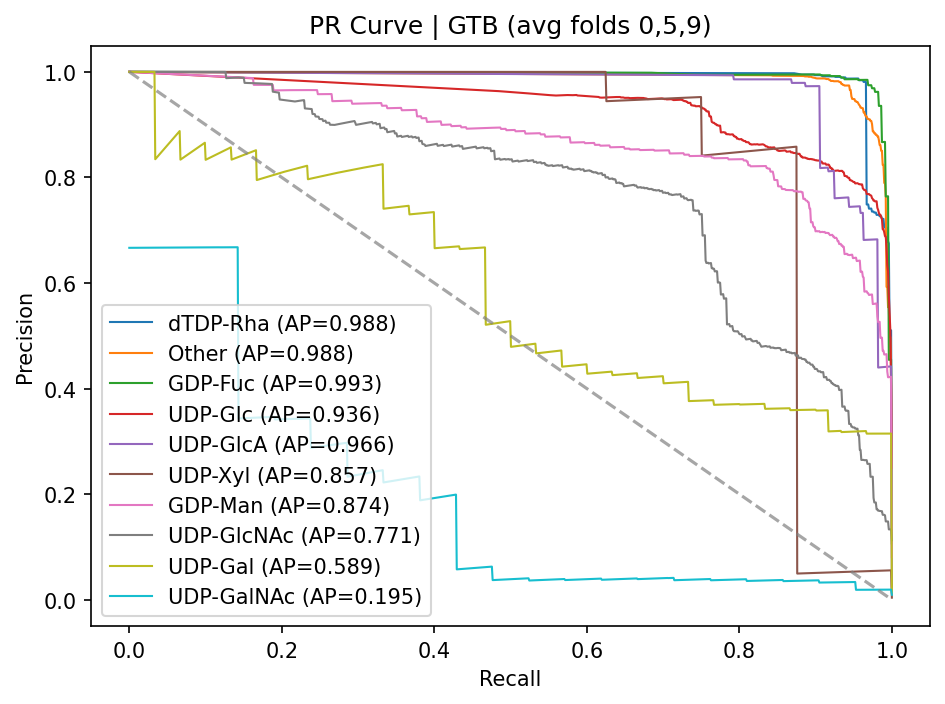

In [53]:
'''
逐个绘制fold的PR曲线 —— 每个底物独立平均 fold 0,5,9
'''

from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 核心配置：切换只需改这里 =====================
fold_type = 'GTB'          # GTA / GTB
plot_mode = "PR"           # ROC = 画ROC曲线 | PR = 画PR曲线
# ==================================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history_auto.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history_auto.npy"

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 标签配置
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [7,1,4,0,3,6,2,8,5]
    else:
        plot_flags = [0,1,6,7,8,4,3,2,5]
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [8,7,9,5,2,0,6,1,3,4]
    else:
        plot_flags = [8,9,7,0,2,5,6,1,3,4]

# ===================== 关键修改：只平均 fold 0,5,9 =====================
use_folds = [1,3,9]
mean_point = np.linspace(0, 1, 1000)
plt.figure(dpi=150)

for flag in plot_flags:
    data_list = roc_history_dict[flag]
    all_y = []

    # 每个底物只在 0,5,9 fold 上做平均
    for fold_idx in use_folds:
        y_bin, y_prob = data_list[fold_idx]
        if plot_mode == "ROC":
            fpr, tpr, _ = roc_curve(y_bin, y_prob)
            interp_y = np.interp(mean_point, fpr, tpr)
        else:
            precision, recall, _ = precision_recall_curve(y_bin, y_prob)
            recall = recall[::-1]
            precision = precision[::-1]
            interp_y = np.interp(mean_point, recall, precision)
        all_y.append(interp_y)

    mean_y = np.mean(all_y, axis=0)
    score = auc(mean_point, mean_y)
    score_name = "AUC" if plot_mode == "ROC" else "AP"

    label = f"{graph_label_dict[flag]} ({score_name}={score:.3f})"
    plt.plot(mean_point, mean_y, linewidth=1, label=label)

# ========== 基准线 & 坐标轴 ==========
if plot_mode == "ROC":
    plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
    plt.xlabel('1-Specificity (FPR)')
    plt.ylabel('Sensitivity (TPR)')
    plt.title(f'ROC Curve | {fold_type} (avg folds 0,5,9)')
    plt.legend(loc='lower right')
else:
    plt.plot([0,1], [1,0], '--', color='gray', alpha=0.7)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve | {fold_type} (avg folds 0,5,9)')
    plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 保存（需要就打开）
# plt.savefig(f'./result/{plot_mode}_{fold_type}_avg059.png', dpi=1200)
# plt.savefig(f'./result/{plot_mode}_{fold_type}_avg059.svg', format='svg')


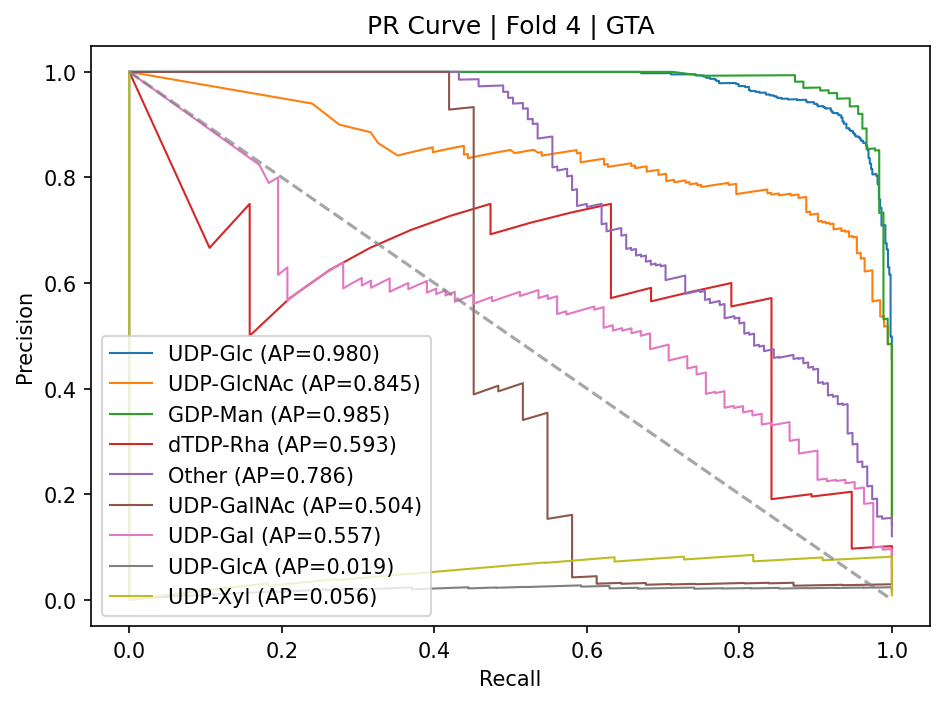

In [16]:
'''
单个 fold + 所有底物：每个底物一条曲线
'''

from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 核心配置 =====================
fold_type = 'GTA'
plot_mode = "PR"
target_fold = 4    # 你想看哪个 fold？改这里！
# ====================================================

# 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 标签配置
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [7,1,4,0,3,6,2,8,5]
    else:
        plot_flags = [0,1,6,7,8,4,3,2,5]
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    if plot_mode == "ROC":
        plot_flags = [8,7,9,5,2,0,6,1,3,4]
    else:
        plot_flags = [8,9,7,0,2,5,6,1,3,4]

# 绘图
plt.figure(dpi=150)

for flag in plot_flags:
    data_list = roc_history_dict[flag]
    
    # ===================== 关键：只取 target_fold =====================
    y_bin, y_prob = data_list[target_fold]

    if plot_mode == "ROC":
        fpr, tpr, _ = roc_curve(y_bin, y_prob)
        score = auc(fpr, tpr)
        x, y = fpr, tpr
        score_name = "AUC"
    else:
        precision, recall, _ = precision_recall_curve(y_bin, y_prob)
        score = auc(recall, precision)
        x, y = recall, precision
        score_name = "AP"

    # 画当前底物在这个fold的曲线
    label = f"{graph_label_dict[flag]} ({score_name}={score:.3f})"
    plt.plot(x, y, linewidth=1, label=label)

# ========== 基准线 & 坐标轴 ==========
if plot_mode == "ROC":
    plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'ROC Curve | Fold {target_fold} | {fold_type}')
    plt.legend(loc='lower right')
else:
    plt.plot([0,1], [1,0], '--', color='gray', alpha=0.7)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve | Fold {target_fold} | {fold_type}')
    plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

# 保存
# plt.savefig(f'./result/{plot_mode}_fold{target_fold}_{fold_type}.png', dpi=1200)


In [8]:
'''
输出每个fold的Micro AP + 平均±标准差
'''

from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import os

# ===================== 配置 =====================
fold_type = 'GTA'
# =================================================

if fold_type == 'GTA':
    # npy_filename = "GTmining_6_6_GTA_pr_roc_history_auto.npy"
    npy_filename = "GTmining_6_6_GTA_pr_roc_history.npy"
    num_classes = 9
elif fold_type == 'GTB':
    # npy_filename = "GTmining_6_6_GTB_pr_roc_history_auto.npy"
    npy_filename = "GTmining_6_6_GTB_pr_roc_history.npy"
    num_classes = 10

roc_history_dict = np.load(os.path.join('./result/', npy_filename), allow_pickle=True).item()

# 存储所有fold的ap
all_micro_ap = []

print(f"========== {fold_type} 每个 Fold 的 Micro AP ==========\n")
for target_fold in range(10):
    all_y_true = []
    all_y_score = []
    for class_idx in range(num_classes):
        y_bin, y_prob = roc_history_dict[class_idx][target_fold]
        all_y_true.extend(y_bin)
        all_y_score.extend(y_prob)
    
    precision, recall, _ = precision_recall_curve(all_y_true, all_y_score)
    micro_ap = auc(recall, precision)
    all_micro_ap.append(micro_ap)
    print(f"Fold {target_fold} | Micro AP = {micro_ap:.4f}")

# 计算平均和标准差
mean_ap = np.mean(all_micro_ap)
std_ap = np.std(all_micro_ap)

print("\n========== 汇总 ==========")
print(f"平均 Micro AP = {mean_ap:.4f} ± {std_ap:.4f}")


========== GTA 每个 Fold 的 Micro AP ==========

Fold 0 | Micro AP = 0.7708
Fold 1 | Micro AP = 0.7472
Fold 2 | Micro AP = 0.8062
Fold 3 | Micro AP = 0.7751
Fold 4 | Micro AP = 0.8760
Fold 5 | Micro AP = 0.8562
Fold 6 | Micro AP = 0.8003
Fold 7 | Micro AP = 0.6911
Fold 8 | Micro AP = 0.7836
Fold 9 | Micro AP = 0.8044

========== 汇总 ==========
平均 Micro AP = 0.7911 ± 0.0496


## 计算准确率指标

In [15]:
import pandas as pd
import os

fold_type = 'GTB'
result_csv_folder = f'./model_param_alldata/'

if fold_type == 'GTA':
    best_epochs = {
        1: 367, 2: 764, 3: 631, 4: 570,
        5: 451, 6: 473, 7: 704, 8: 292,
        9: 364, 10: 353
    }
elif fold_type == 'GTB':
    best_epochs = {
        1: 206, 2: 245, 3: 152, 4: 141,
        5: 225, 6: 137, 7: 119, 8: 216,
        9: 205, 10: 143
    }

accuracy_results = {
    'UDP-Glc': [],
    'UDP-GlcNAc': []
}
for fold in range(1, 11):
    csv_folder = os.path.join(result_csv_folder, f'GTmining_6_6_{fold_type}_fold{fold}')
    csv_list = [x for x in os.listdir(csv_folder) if x.endswith('.csv') and 'validation_pred_labels_epoch' in x]
    csv_dict = {x.split('_')[4]: x for x in csv_list}
    try:
        df = pd.read_csv(os.path.join(csv_folder, csv_dict[str(best_epochs[fold])]))
    except Exception as e:
        print(f"Error reading CSV for fold {fold}: {e}")
        continue
    for l in ['UDP-Glc', 'UDP-GlcNAc']:
        df_fold_l = df.loc[df['Real_Label'] == l]
        accuracy = (df_fold_l['Predict_Label'] == df_fold_l['Real_Label']).mean()
        accuracy_results[l].append(accuracy)

# 计算每个类别的平均准确率
for l in accuracy_results:
    mean_accuracy = sum(accuracy_results[l]) / len(accuracy_results[l])
    print(f"Category {l}: Mean Accuracy = {mean_accuracy:.4f}")




Error reading CSV for fold 4: '141'
Category UDP-Glc: Mean Accuracy = 0.9792
Category UDP-GlcNAc: Mean Accuracy = 0.8002


In [10]:
df

,ID_Card,Real_Label,Predict_Label
0,GT20_AAQ76839_1,UDP-Glc,UDP-Glc
1,GT20_ABJ01243_1,UDP-Glc,UDP-Glc
2,GT20_ABX20921_1,UDP-Glc,UDP-Glc
3,GT20_ADE88919_1,UDP-Glc,UDP-Glc
4,GT20_ADN70927_1,UDP-Glc,UDP-Glc
...,...,...,...
3769,GT30_QEE36976_1,Other,UDP-GlcNAc
3770,GT30_QPN68872_1,Other,Other
3771,GT30_ABQ27390_1,Other,Other
3772,GT107_QPM90079_1,Other,Other


# 消融实验分析结果

## 全特征评估

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTA'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    # if fold == 3:
    #     continue
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")


Fold type GTB, Fold: 1, Max Val F1 Score: 0.8913334586680826, Best Epoch: 483
Fold type GTB, Fold: 2, Max Val F1 Score: 0.7663228224239236, Best Epoch: 404
Fold type GTB, Fold: 3, Max Val F1 Score: 0.7536282530466846, Best Epoch: 462
Fold type GTB, Fold: 4, Max Val F1 Score: 0.7684039384517768, Best Epoch: 483
Fold type GTB, Fold: 5, Max Val F1 Score: 0.8018020886744562, Best Epoch: 428
Fold type GTB, Fold: 6, Max Val F1 Score: 0.7950383478817663, Best Epoch: 427
Fold type GTB, Fold: 7, Max Val F1 Score: 0.7079288659362848, Best Epoch: 393
Fold type GTB, Fold: 8, Max Val F1 Score: 0.6974633264704687, Best Epoch: 302
Fold type GTB, Fold: 9, Max Val F1 Score: 0.7810649361245214, Best Epoch: 345
Fold type GTB, Fold: 10, Max Val F1 Score: 0.7861377751822867, Best Epoch: 315


In [6]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [7]:
fold_num = 1

param_folder = f'{log_save_folder}{fold_num}'
print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()



=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 655
number of graphs is 16122
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 65
model init finished
MODEL::::::: diffpool


In [8]:
from sklearn.metrics import auc, roc_curve

roc_history_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}


fold_num = 5


param_folder = f'{log_save_folder}{fold_num}'
print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

epoch = best_epochs[fold_num]

begin_time = time.time()
print("\nEPOCH ###### {} ######".format(epoch))
if epoch is not None and prog_args.save_dir is not None:
    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(epoch), weights_only=True
        )
    )

id_card_protein = {}
# validation test
with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
    for dd in f.readlines():
        dd = dd.split('\n')[0].split('===')
        id_card_protein[dd[1]] = dd[0]

model.eval()
correct_label = 0
with torch.no_grad():
    val_pred_indi = torch.tensor([], device='cuda')
    val_label_indi = torch.tensor([], device='cuda')
    val_pred_proba = torch.tensor([], device='cuda')
    for batch_idx, (batch_graph, graph_labels) in enumerate(test_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        ypred = model(batch_graph)
        ypred_proba = torch.nn.Softmax(dim=1)(ypred)
        indi = torch.argmax(ypred, dim=1)
        val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
        val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
        val_pred_proba = torch.cat((val_pred_proba, ypred_proba), dim=0)
        correct = torch.sum(indi == graph_labels)
        correct_label += correct.item()

if fold_type == 'GTA':
    num_classes = 9
elif fold_type == 'GTB':
    num_classes = 10

y_true = val_label_indi.cpu().numpy()
y_score = val_pred_proba.cpu().numpy()
for plot_flag in range(num_classes):
    # 构造二分类标签：当前类别=1，其余=0
    y_binary = (y_true == plot_flag).astype(int)
    y_prob = y_score[:, plot_flag]
    # 保存真实标签 + 预测概率（万能数据！ROC/PRC都能用）
    roc_history_dict[plot_flag].append([y_binary, y_prob])
        


=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold5', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================

EPOCH ###### 428 ######


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [9]:
# 保存roc_hostory
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history_fold5.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history_fold5.npy"
np.save(os.path.join('./model_param_alldata_abl/', npy_filename), roc_history_dict)

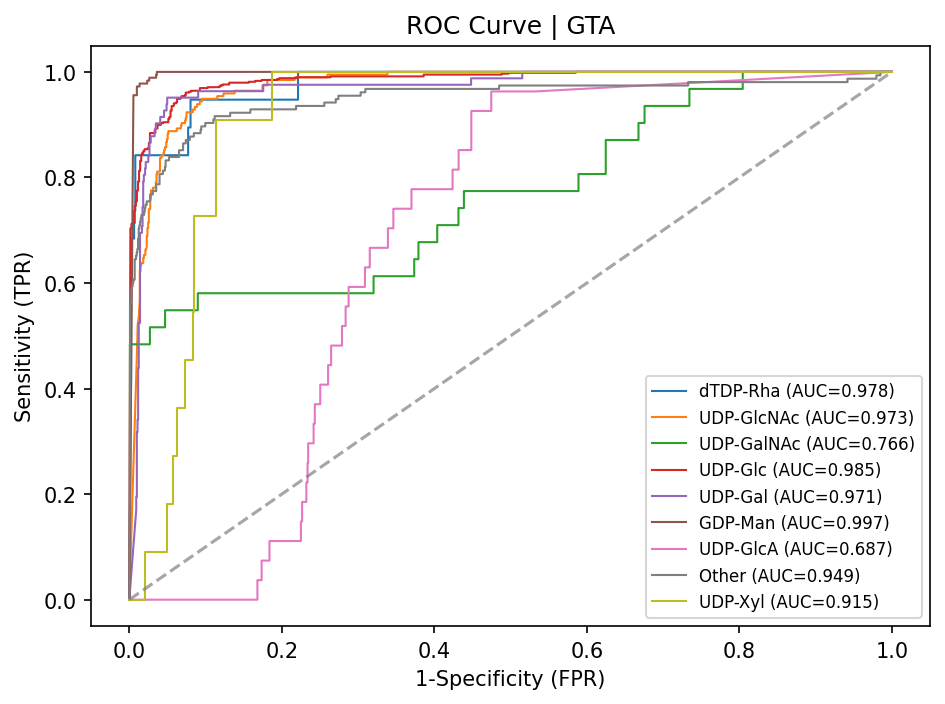

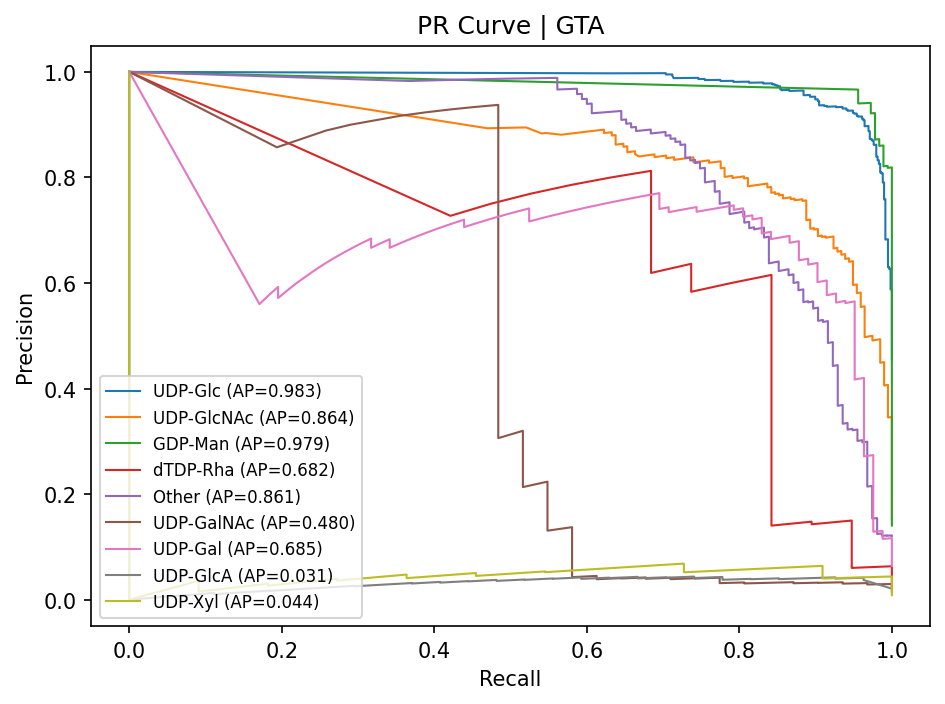


【GTA】 指标汇总报告 (AUC计算方式: Micro)

>>> 总体指标 (Overall)
--------------------------------------------------
  1. ROC-AUC (Micro):  0.9589
  2. PR-AUC  (Micro):  0.8881
  3. F1-Score (Micro): 0.8363
  4. MCC:               0.7780
  5. Accuracy:          0.8363
--------------------------------------------------

>>> 分底物详细指标 (Per-substrate)
-----------------------------------------------------------------------------------------------
Substrate       | ROC-AUC    | PR-AUC     | F1-Score   | MCC       
-----------------------------------------------------------------------------------------------
UDP-Glc         | 0.9846     | 0.9831     | 0.9243     | 0.8623    
UDP-GlcNAc      | 0.9730     | 0.8639     | 0.7919     | 0.7565    
UDP-GlcA        | 0.6866     | 0.0306     | 0.0000     | -0.0082   
UDP-Gal         | 0.9711     | 0.6855     | 0.7250     | 0.7071    
UDP-GalNAc      | 0.7664     | 0.4798     | 0.6000     | 0.6111    
UDP-Xyl         | 0.9151     | 0.0445     | 0.0000     | -0.0037  

In [8]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             roc_auc_score, f1_score, matthews_corrcoef, accuracy_score)
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 核心配置 =====================
fold_type = 'GTA'          # GTA / GTB
target_fold = 0             # 由于你之前保存的是 fold5，这里列表索引只有 0
save_dir = './result_figs' # 图片保存文件夹
# =====================================================

# 创建保存文件夹
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. 加载数据
if fold_type == 'GTA':
    npy_filename = "GTmining_6_6_GTA_roc_history_fold5.npy"
elif fold_type == 'GTB':
    npy_filename = "GTmining_6_6_GTB_roc_history_fold5.npy"

roc_history_dict = np.load(os.path.join('./model_param_alldata_abl/', npy_filename), allow_pickle=True).item()

# 2. 标签配置
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    # 绘图顺序 (保持你原来的审美顺序)
    order_roc = [7,1,4,0,3,6,2,8,5]
    order_pr  = [0,1,6,7,8,4,3,2,5]
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    order_roc = [8,7,9,5,2,0,6,1,3,4]
    order_pr  = [8,9,7,0,2,5,6,1,3,4]

# 3. 数据重构：恢复多分类的 y_true, y_score, y_pred
# ---------------------------------------------------------
sample_flag = order_roc[0]
y_bin_example, _ = roc_history_dict[sample_flag][target_fold]
n_samples = len(y_bin_example)
n_classes = len(graph_label_dict)

y_true_multiclass = np.zeros(n_samples, dtype=int)
y_score_multiclass = np.zeros((n_samples, n_classes))

for flag in graph_label_dict.keys():
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    y_true_multiclass[y_bin == 1] = flag
    y_score_multiclass[:, flag] = y_prob

y_pred_multiclass = np.argmax(y_score_multiclass, axis=1)
# ---------------------------------------------------------

# 4. 预先计算所有指标 (用于打印)
# ---------------------------------------------------------
per_class_results = {
    'Name': [], 'ROC-AUC': [], 'PR-AUC': [], 'F1': [], 'MCC': []
}

# 为了计算 Micro，我们需要先收集所有的 y_true 和 y_score (展平)
y_true_micro = []
y_score_micro = []

for flag in graph_label_dict.keys():
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    y_pred_bin = (y_pred_multiclass == flag).astype(int)
    
    # 收集用于 Micro 计算
    y_true_micro.extend(y_bin)
    y_score_micro.extend(y_prob)
    
    # 计算各类别指标
    fpr, tpr, _ = roc_curve(y_bin, y_prob)
    roc_auc_val = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_bin, y_prob)
    pr_auc_val = auc(recall, precision)
    
    f1_val = f1_score(y_bin, y_pred_bin, average='binary')
    mcc_val = matthews_corrcoef(y_bin, y_pred_bin)
    
    per_class_results['Name'].append(graph_label_dict[flag])
    per_class_results['ROC-AUC'].append(roc_auc_val)
    per_class_results['PR-AUC'].append(pr_auc_val)
    per_class_results['F1'].append(f1_val)
    per_class_results['MCC'].append(mcc_val)

# 转换为 numpy 数组方便计算
y_true_micro = np.array(y_true_micro)
y_score_micro = np.array(y_score_micro)

# --- 计算总体 Micro 指标 ---
# 1. Micro ROC-AUC
fpr_micro, tpr_micro, _ = roc_curve(y_true_micro, y_score_micro)
overall_roc_auc_micro = auc(fpr_micro, tpr_micro)

# 2. Micro PR-AUC
precision_micro, recall_micro, _ = precision_recall_curve(y_true_micro, y_score_micro)
overall_pr_auc_micro = auc(recall_micro, precision_micro)

# 3. F1 Micro
overall_f1_micro = f1_score(y_true_multiclass, y_pred_multiclass, average='micro')

# 4. MCC (Multi-class)
overall_mcc = matthews_corrcoef(y_true_multiclass, y_pred_multiclass)

# 5. Accuracy
overall_accuracy = accuracy_score(y_true_multiclass, y_pred_multiclass)
# ---------------------------------------------------------

# 5. 绘图函数：绘制 ROC 曲线
# ---------------------------------------------------------
plt.figure(dpi=150)
for flag in order_roc:
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    fpr, tpr, _ = roc_curve(y_bin, y_prob)
    score = auc(fpr, tpr)
    
    label = f"{graph_label_dict[flag]} (AUC={score:.3f})"
    plt.plot(fpr, tpr, linewidth=1, label=label)

# 绘制 Micro 平均线 (可选，如果你想突出 Micro)
# plt.plot(fpr_micro, tpr_micro, 'k--', linewidth=2, label=f'Micro Avg (AUC={overall_roc_auc_micro:.3f})')

plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
plt.xlabel('1-Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.title(f'ROC Curve | {fold_type}')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()

# 保存 ROC 图
roc_save_path_png = os.path.join(save_dir, f'ROC_{fold_type}.png')
roc_save_path_svg = os.path.join(save_dir, f'ROC_{fold_type}.svg')
# plt.savefig(roc_save_path_png, dpi=1200, bbox_inches='tight')
# plt.savefig(roc_save_path_svg, format='svg', bbox_inches='tight')
# print(f"ROC图已保存至: {roc_save_path_png}")
plt.show()
# ---------------------------------------------------------

# 6. 绘图函数：绘制 PR 曲线
# ---------------------------------------------------------
plt.figure(dpi=150)
for flag in order_pr:
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    precision, recall, _ = precision_recall_curve(y_bin, y_prob)
    score = auc(recall, precision)
    
    label = f"{graph_label_dict[flag]} (AP={score:.3f})"
    plt.plot(recall, precision, linewidth=1, label=label)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'PR Curve | {fold_type}')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()

# 保存 PR 图
pr_save_path_png = os.path.join(save_dir, f'PR_{fold_type}.png')
pr_save_path_svg = os.path.join(save_dir, f'PR_{fold_type}.svg')
# plt.savefig(pr_save_path_png, dpi=1200, bbox_inches='tight')
# plt.savefig(pr_save_path_svg, format='svg', bbox_inches='tight')
# print(f"PR图已保存至: {pr_save_path_png}")
plt.show()
# ---------------------------------------------------------

# 7. 命令行输出
# ==============================================================================
print("\n" + "="*80)
print(f"【{fold_type}】 指标汇总报告 (AUC计算方式: Micro)")
print("="*80)

print("\n>>> 总体指标 (Overall)")
print("-" * 50)
print(f"  1. ROC-AUC (Micro):  {overall_roc_auc_micro:.4f}")
print(f"  2. PR-AUC  (Micro):  {overall_pr_auc_micro:.4f}")
print(f"  3. F1-Score (Micro): {overall_f1_micro:.4f}")
print(f"  4. MCC:               {overall_mcc:.4f}")
print(f"  5. Accuracy:          {overall_accuracy:.4f}")
print("-" * 50)

print("\n>>> 分底物详细指标 (Per-substrate)")
print("-" * 95)
print(f"{'Substrate':<15} | {'ROC-AUC':<10} | {'PR-AUC':<10} | {'F1-Score':<10} | {'MCC':<10}")
print("-" * 95)
# 按顺序打印 (这里按类别顺序打印，如果你想按绘图顺序打印可自行调整)
for i in range(len(graph_label_dict)):
    name = per_class_results['Name'][i]
    print(f"{name:<15} | "
          f"{per_class_results['ROC-AUC'][i]:<10.4f} | "
          f"{per_class_results['PR-AUC'][i]:<10.4f} | "
          f"{per_class_results['F1'][i]:<10.4f} | "
          f"{per_class_results['MCC'][i]:<10.4f}")
print("-" * 95)


## 消融评估

In [2]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTB'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold5_'
error_fold = 0
for abl_type in ['charge', 'hbond', 'hphob', 'si', 'xyz']:
    log_dir = f'./model_param_alldata_abl/{log_save_folder}{abl_type}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    # if fold == 3:
    #     continue
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[abl_type] = beat_epoch
    print(f"Fold type {fold_type}, Ablation Type: {abl_type}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")

# GTA
# best_epochs['si'] = 234
# best_epochs['xyz'] = 411

# GTB
best_epochs['charge'] = 108
best_epochs['hbond'] = 50
best_epochs['hphob'] = 237
# best_epochs['si'] = 50

best_epochs

Fold type GTB, Ablation Type: charge, Max Val F1 Score: 0.7841191022693599, Best Epoch: 335
Fold type GTB, Ablation Type: hbond, Max Val F1 Score: 0.7610273414909654, Best Epoch: 163
Fold type GTB, Ablation Type: hphob, Max Val F1 Score: 0.7934866048877361, Best Epoch: 283
Fold type GTB, Ablation Type: si, Max Val F1 Score: 0.8252285485389945, Best Epoch: 448
Fold type GTB, Ablation Type: xyz, Max Val F1 Score: 0.6545352221376033, Best Epoch: 231


{'charge': 108, 'hbond': 50, 'hphob': 192, 'si': 448, 'xyz': 231}

In [4]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )

class customreaddata:
    """
    A custom dataset class to read graph data from specified text files for prediction.
    Assumes the following files exist in raw_dir under a subdirectory named 'name':
    - {name}_A.txt (edge list)
    - {name}_graph_indicator.txt (which graph each node belongs to)
    - {name}_graph_labels.txt (labels for each graph) - This might be dummy for prediction
    - {name}_node_attributes.txt (features for each node)

    Parameters
    ----------
    name : str
        Name of the dataset directory and prefix for files (e.g., 'GTmining').
    raw_dir : str
        Path to the directory containing the dataset folder.
    """

    def __init__(self, name, raw_dir):
        self.name = name
        self.raw_dir = raw_dir
        self.save_dir = os.path.join(raw_dir, name) # Use raw_dir as base, create save path inside
        os.makedirs(self.save_dir, exist_ok=True) # Ensure save directory exists for potential caching

        # Initialize attributes that will be set by process()
        self.graph_lists = []
        self.graph_labels = []
        self.item_ids = []  # 新增：存储每个图的item_id
        self.max_num_node = 0
        self.num_labels = None # May not be relevant for prediction

        # Process the raw data files
        self.process()

    def _file_path(self, category):
        """Constructs the path to a specific data file."""
        return os.path.join(self.raw_dir, f"{self.name}_{category}.txt")

    @staticmethod
    def _idx_from_zero(idx_tensor):
        """Adjusts indices to be 0-based."""
        # Assuming node and graph indices in your files are 1-based.
        # If they are already 0-based, this step is unnecessary or needs adjustment.
        # Check the first few lines of your GTmining_graph_indicator.txt to confirm.
        # If they are 0-based, remove this function or make it a no-op.
        # For now, assuming 1-based as per TUDataset standard.
        min_val = np.min(idx_tensor)
        if min_val == 0:
             # If already 0-based, return as is or handle accordingly
             # This might be the case, adjust logic if needed
             print(f"Warning: Indices in file seem to be 0-based (min={min_val}). Proceeding assuming 0-based.")
             return idx_tensor
        else:
             # Standard 1-based to 0-based conversion
             return idx_tensor - 1 # More standard than subtracting min if known to start at 1

    def process(self):
        """
        Loads data from text files and constructs a list of DGLGraphs.
        """
        print(f"Processing custom dataset: {self.name}")

        # --- 1. Load Edge List ---
        print(f"Loading edges from {self._file_path('A')}")
        # Load edges, assuming 1-based indexing initially
        edge_data_raw = np.genfromtxt(self._file_path("A"), delimiter=",", dtype=int)
        if edge_data_raw.ndim == 1:
            # If only one edge, reshape to (1, 2)
            edge_data_raw = edge_data_raw.reshape(1, -1)
        # Convert to 0-based indices
        edge_data_0_based = self._idx_from_zero(edge_data_raw)
        # DGL expects source and destination arrays
        src_nodes = edge_data_0_based[:, 0]
        dst_nodes = edge_data_0_based[:, 1]

        # --- 2. Load Graph Indicator (which graph each node belongs to) ---
        print(f"Loading graph indicators from {self._file_path('graph_indicator')}")
        node_graph_ids_raw = np.loadtxt(self._file_path("graph_indicator"), dtype=int)
        # Convert graph IDs to 0-based indices
        node_graph_ids = self._idx_from_zero(node_graph_ids_raw)
        num_total_nodes_in_file = len(node_graph_ids_raw)

        # --- 3. Load Graph Labels (might be dummy) ---
        print(f"Loading graph labels from {self._file_path('graph_labels')}")
        try:
            graph_labels_raw = np.loadtxt(self._file_path("graph_labels"), dtype=int)
            # Convert graph labels to 0-based indices if needed, though for classification
            # they often represent class IDs starting from 0 or 1. Adjust if necessary.
            # For prediction, these might just be placeholders.
            self.graph_labels = graph_labels_raw # Keep original values for now, adjust if necessary
            self.num_labels = max(self.graph_labels) + 1 if len(self.graph_labels) > 0 else 0
        except FileNotFoundError:
            print(f"Warning: Graph labels file {self._file_path('graph_labels')} not found. Using dummy labels (e.g., 0).")
            num_graphs_in_file = len(set(node_graph_ids))
            self.graph_labels = np.zeros(num_graphs_in_file, dtype=int) # Dummy labels
            self.num_labels = 1 # Or set to None if not applicable

        # --- 4. Load Item IDs (新增逻辑) ---
        print(f"Loading item IDs from {self._file_path('itemID')}")
        try:
            # 读取itemID文件，支持整数或字符串类型的ID
            self.item_ids = np.loadtxt(self._file_path("itemID"), dtype=str).tolist()
            
            # 验证item_id数量是否与图数量匹配
            num_graphs_in_file = len(set(node_graph_ids))
            if len(self.item_ids) != num_graphs_in_file:
                raise ValueError(
                    f"Number of item IDs ({len(self.item_ids)}) does not match number of graphs ({num_graphs_in_file})."
                )
        except FileNotFoundError:
            print(f"Warning: Item ID file {self._file_path('itemID')} not found. Using graph index as item ID.")
            num_graphs_in_file = len(set(node_graph_ids))
            self.item_ids = [str(i) for i in range(num_graphs_in_file)]  # 使用索引作为默认ID


        # --- 4. Load Node Attributes ---
        print(f"Loading node attributes from {self._file_path('node_attributes')}")
        try:
            node_attributes = np.loadtxt(self._file_path("node_attributes"), delimiter=",")
            if node_attributes.ndim == 1:
                # If features are 1D (one feature per node), reshape to (num_nodes, 1)
                node_attributes = np.expand_dims(node_attributes, axis=1)
            print(f"Loaded node attributes with shape: {node_attributes.shape}")
            if node_attributes.shape[0] != num_total_nodes_in_file:
                 raise ValueError(f"Number of rows in node_attributes ({node_attributes.shape[0]}) does not match number of nodes indicated by graph_indicator ({num_total_nodes_in_file}).")
        except FileNotFoundError:
            print(f"Warning: Node attributes file {self._file_path('node_attributes')} not found. Graphs will have no node features (ndata['feat'] will not be set initially).")
            node_attributes = None


        # --- 5. Create a Base Graph with All Nodes and Edges ---
        # This graph contains all nodes from all graphs, connected by the provided edges.
        num_nodes_in_base_graph = int(np.max(src_nodes)) + 1 if len(src_nodes) > 0 else 0
        # Ensure num_nodes includes any isolated nodes that might only appear in graph_indicator
        num_nodes_in_base_graph = max(num_nodes_in_base_graph, num_total_nodes_in_file)

        if num_nodes_in_base_graph == 0:
            print("Warning: No nodes or edges found in the data files.")
            self.graph_lists = []
            return

        base_graph = dgl.graph(([], []), num_nodes=num_nodes_in_base_graph)
        base_graph.add_edges(src_nodes, dst_nodes)

        # Assign node attributes to the base graph if available
        if node_attributes is not None:
            base_graph.ndata['feat'] = torch.tensor(node_attributes, dtype=torch.float32)

        # --- 6. Split the Base Graph into Individual Graphs ---
        self.graph_lists = []
        self.max_num_node = 0

        num_expected_graphs = len(set(node_graph_ids))
        print(f"Found {num_expected_graphs} graphs based on graph_indicator.")

        for graph_id in range(num_expected_graphs):
            # Find the nodes belonging to the current graph (graph_id)
            node_mask = (node_graph_ids == graph_id)
            node_indices_for_graph = np.where(node_mask)[0] # Get 0-based indices of nodes in this graph

            if len(node_indices_for_graph) == 0:
                print(f"Warning: Graph ID {graph_id} has no nodes according to graph_indicator.")
                # Create an empty graph for this ID
                g_sub = dgl.graph(([], []), num_nodes=0)
                # Add a dummy feature tensor if original had features, though shape might be tricky for 0 nodes
                # Often, empty graphs might need special handling downstream.
                # For now, just create the empty graph.
            else:
                # Extract the subgraph corresponding to these nodes
                g_sub = base_graph.subgraph(node_indices_for_graph)

                # The subgraph's nodes have new IDs (0, 1, ...). The original features are preserved based on the subgraph operation.
                # If node_attributes was loaded, 'feat' is already in g_sub.ndata.
                # Check if 'feat' exists, otherwise features were not available.
                if 'feat' not in g_sub.ndata:
                     print(f"  Graph {graph_id}: No node features available.")


            self.graph_lists.append(g_sub)

            if g_sub.num_nodes() > self.max_num_node:
                self.max_num_node = g_sub.num_nodes()

        print(f"Successfully processed {len(self.graph_lists)} graphs.")
        print(f"Max number of nodes in a single graph: {self.max_num_node}")


    def __getitem__(self, idx):
        """
        Gets the graph and its label at the given index.

        Parameters
        ---------
        idx : int
            The sample index.

        Returns
        -------
        dgl.DGLGraph
            The graph object, potentially with node features in `ndata['feat']`.
        torch.Tensor
            The label tensor for the graph (could be dummy for prediction).
        """
        if idx < 0 or idx >= len(self):
             raise IndexError(f"Index {idx} is out of range for dataset with {len(self)} items.")
        g = self.graph_lists[idx]
        label = torch.tensor(self.graph_labels[idx], dtype=torch.int64) if self.graph_labels is not None else torch.tensor(0, dtype=torch.int64) # Return a dummy label if not set
        item_id = self.item_ids[idx]  # 新增：获取对应索引的item_id

        return g, label, item_id

    def __len__(self):
        """
        Returns the number of graphs in the dataset.
        """
        return len(self.graph_lists)

    @property
    def num_classes(self):
        """Returns the number of classes (uses num_labels)."""
        return int(self.num_labels) if self.num_labels is not None else 0 # Return 0 if not set
    
    def statistics(self):
        """
        返回数据集的三个关键统计信息，适配你的调用格式：
        input_dim, label_dim, max_num_node
        """
        # 1. 节点特征维度（如果没有特征则返回 0）
        if len(self.graph_lists) > 0 and 'feat' in self.graph_lists[0].ndata:
            input_dim = self.graph_lists[0].ndata['feat'].shape[1]
        else:
            input_dim = 0

        # 2. 标签维度（类别数量）
        label_dim = self.num_classes

        # 3. 最大节点数（你已经在 process 里算好了）
        max_num_node = self.max_num_node

        return input_dim, label_dim, max_num_node

In [5]:
abl_type = 'hphob' # ['charge', 'hbond', 'hphob', 'si', 'xyz']

fold_num = 5

print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}_{abl_type}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                                batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata_abl",
                                load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}_{abl_type}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                                batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata_abl",
                                load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = customreaddata(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata_id_abl_{abl_type}/fold{fold_num}/train/')
dataset_validation = customreaddata(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata_id_abl_{abl_type}/fold{fold_num}/validation/')
dataset_test = customreaddata(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata_id_abl_{abl_type}/fold{fold_num}/test/')

train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels, item_ids) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()



=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold5_hphob', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0,
clip=inf, batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type='meanpool',
dropout=0.0, method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata_abl',
load_epoch=-1, data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64,
family_fold_type='GTB')
================================================加载数据================================================
Processing custom dataset: GTmining
Loading edges from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/train/GTmining_A.txt
Loading graph indicators from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/train/GTmining_graph_indicator.txt
Loading graph labels from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/train/GTmining_graph_labels.txt
Loading item IDs from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/tr

In [ ]:
from sklearn.metrics import auc, roc_curve

roc_history_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}

fold_num = 5


param_folder = f'{log_save_folder}{fold_num}'
print("{:=^100}".format('prog_args'))
# 尝试
if fold_type == 'GTA':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}_{abl_type}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                                batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata_abl",
                                load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
elif fold_type == 'GTB':
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}_{abl_type}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                                batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                                dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata_abl",
                                load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)

print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_test = customreaddata(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata_id_abl_{abl_type}/fold{fold_num}/test/')
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

epoch = best_epochs[abl_type]

# epoch = 237

begin_time = time.time()
print("\nEPOCH ###### {} ######".format(epoch))
if epoch is not None and prog_args.save_dir is not None:
    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(epoch), weights_only=True
        )
    )


model.eval()
correct_label = 0
with torch.no_grad():
    val_pred_indi = torch.tensor([], device='cuda')
    val_label_indi = torch.tensor([], device='cuda')
    val_pred_proba = torch.tensor([], device='cuda')
    for batch_idx, (batch_graph, graph_labels, item_ids) in enumerate(test_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        ypred = model(batch_graph)
        ypred_proba = torch.nn.Softmax(dim=1)(ypred)
        indi = torch.argmax(ypred, dim=1)
        val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
        val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
        val_pred_proba = torch.cat((val_pred_proba, ypred_proba), dim=0)
        correct = torch.sum(indi == graph_labels)
        correct_label += correct.item()

if fold_type == 'GTA':
    num_classes = 9
elif fold_type == 'GTB':
    num_classes = 10

y_true = val_label_indi.cpu().numpy()
y_score = val_pred_proba.cpu().numpy()
for plot_flag in range(num_classes):
    # 构造二分类标签：当前类别=1，其余=0
    y_binary = (y_true == plot_flag).astype(int)
    y_prob = y_score[:, plot_flag]
    # 保存真实标签 + 预测概率（万能数据！ROC/PRC都能用）
    roc_history_dict[plot_flag].append([y_binary, y_prob])
        


=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold5_hphob', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0,
clip=inf, batch_size=128, epoch=500, n_worker=10, gc_per_block=3, aggregator_type='meanpool',
dropout=0.0, method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata_abl',
load_epoch=-1, data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64,
family_fold_type='GTB')
================================================加载数据================================================
Processing custom dataset: GTmining
Loading edges from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/test/GTmining_A.txt
Loading graph indicators from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/test/GTmining_graph_indicator.txt
Loading graph labels from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/test/GTmining_graph_labels.txt
Loading item IDs from ../data/dl_data/GTB_alldata_id_abl_hphob/fold5/test/

In [20]:
# 保存roc_hostory
if fold_type == 'GTA':
    npy_filename = f"GTmining_6_6_GTA_roc_history_fold5_abl_{abl_type}.npy"
elif fold_type == 'GTB':
    npy_filename = f"GTmining_6_6_GTB_roc_history_fold5_abl_{abl_type}.npy"
np.save(os.path.join('./model_param_alldata_abl/', npy_filename), roc_history_dict)

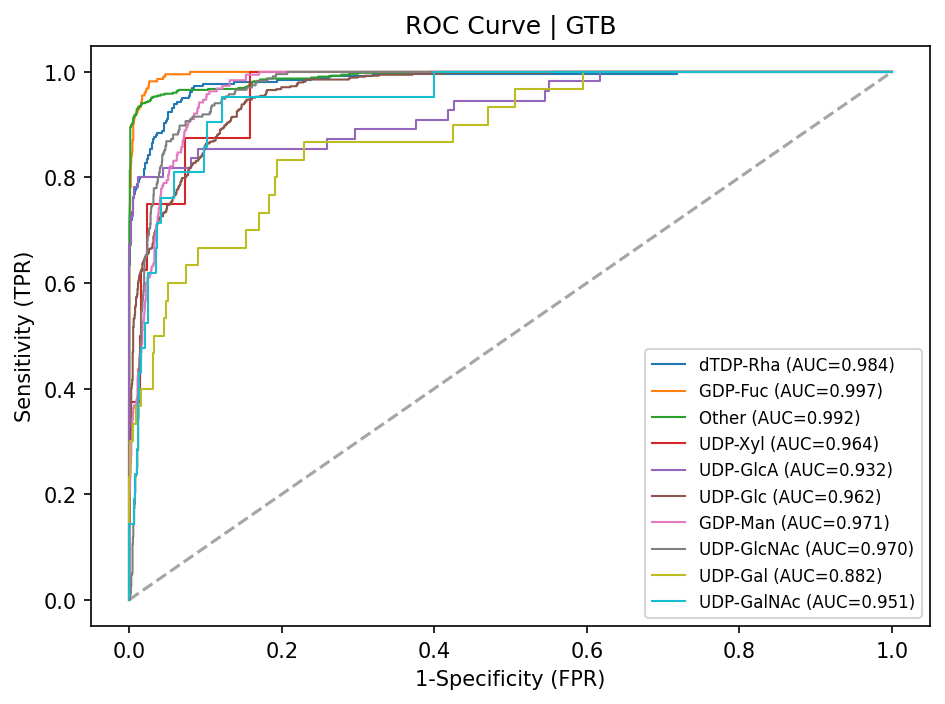

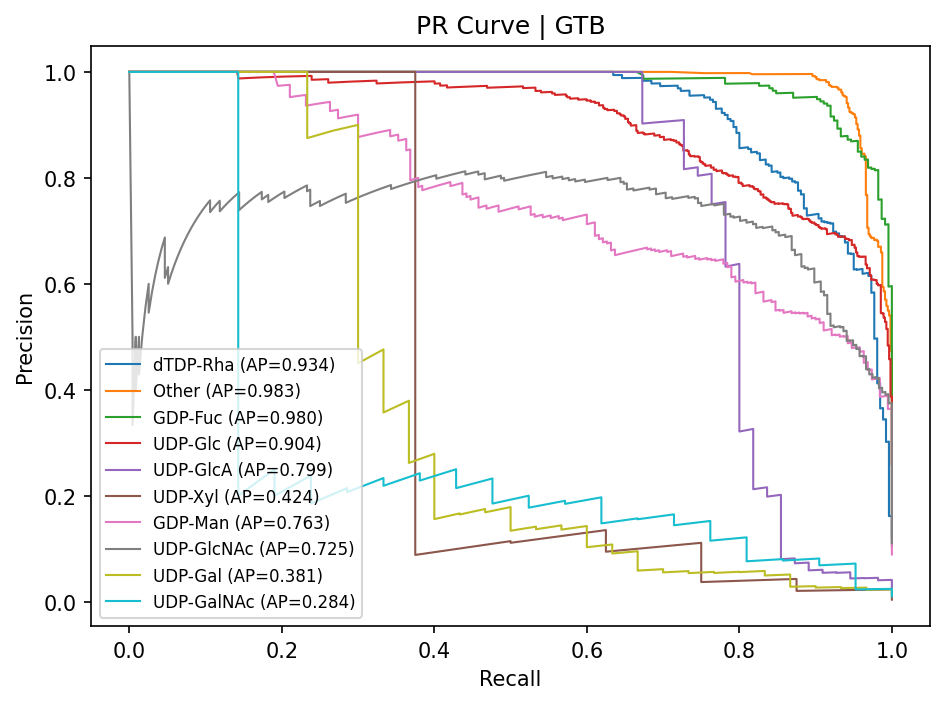


【GTB】 指标汇总报告 (AUC计算方式: Micro)

>>> 总体指标 (Overall)
--------------------------------------------------
  1. ROC-AUC (Micro):  0.9727
  2. PR-AUC  (Micro):  0.8747
  3. F1-Score (Micro): 0.7726
  4. MCC:               0.7239
  5. Accuracy:          0.7726
--------------------------------------------------

>>> 分底物详细指标 (Per-substrate)
-----------------------------------------------------------------------------------------------
Substrate       | ROC-AUC    | PR-AUC     | F1-Score   | MCC       
-----------------------------------------------------------------------------------------------
UDP-Glc         | 0.9617     | 0.9036     | 0.7922     | 0.7218    
UDP-GlcNAc      | 0.9705     | 0.7247     | 0.5920     | 0.5790    
UDP-GlcA        | 0.9321     | 0.7985     | 0.7736     | 0.7684    
UDP-Gal         | 0.8816     | 0.3813     | 0.3000     | 0.2973    
UDP-GalNAc      | 0.9506     | 0.2836     | 0.1714     | 0.1683    
UDP-Xyl         | 0.9645     | 0.4236     | 0.5455     | 0.6117   

In [22]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             roc_auc_score, f1_score, matthews_corrcoef, accuracy_score)
import matplotlib.pyplot as plt
import numpy as np
import os

# ===================== 核心配置 =====================
fold_type = 'GTB'          # GTA / GTB
abl_type = 'hphob'       # ['charge', 'hbond', 'hphob', 'si', 'xyz']
target_fold = 0             # 由于你之前保存的是 fold5，这里列表索引只有 0
save_dir = './result_figs' # 图片保存文件夹
# =====================================================

# 创建保存文件夹
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. 加载数据
if fold_type == 'GTA':
    npy_filename = f"GTmining_6_6_GTA_roc_history_fold5_abl_{abl_type}.npy"
elif fold_type == 'GTB':
    npy_filename = f"GTmining_6_6_GTB_roc_history_fold5_abl_{abl_type}.npy"

roc_history_dict = np.load(os.path.join('./model_param_alldata_abl/', npy_filename), allow_pickle=True).item()

# 2. 标签配置
if fold_type == 'GTA':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'dTDP-Rha',8:'Other'
    }
    # 绘图顺序 (保持你原来的审美顺序)
    order_roc = [7,1,4,0,3,6,2,8,5]
    order_pr  = [0,1,6,7,8,4,3,2,5]
elif fold_type == 'GTB':
    graph_label_dict = {
        0:'UDP-Glc',1:'UDP-GlcNAc',2:'UDP-GlcA',3:'UDP-Gal',4:'UDP-GalNAc',
        5:'UDP-Xyl',6:'GDP-Man',7:'GDP-Fuc',8:'dTDP-Rha',9:'Other'
    }
    order_roc = [8,7,9,5,2,0,6,1,3,4]
    order_pr  = [8,9,7,0,2,5,6,1,3,4]

# 3. 数据重构：恢复多分类的 y_true, y_score, y_pred
# ---------------------------------------------------------
sample_flag = order_roc[0]
y_bin_example, _ = roc_history_dict[sample_flag][target_fold]
n_samples = len(y_bin_example)
n_classes = len(graph_label_dict)

y_true_multiclass = np.zeros(n_samples, dtype=int)
y_score_multiclass = np.zeros((n_samples, n_classes))

for flag in graph_label_dict.keys():
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    y_true_multiclass[y_bin == 1] = flag
    y_score_multiclass[:, flag] = y_prob

y_pred_multiclass = np.argmax(y_score_multiclass, axis=1)
# ---------------------------------------------------------

# 4. 预先计算所有指标 (用于打印)
# ---------------------------------------------------------
per_class_results = {
    'Name': [], 'ROC-AUC': [], 'PR-AUC': [], 'F1': [], 'MCC': []
}

# 为了计算 Micro，我们需要先收集所有的 y_true 和 y_score (展平)
y_true_micro = []
y_score_micro = []

for flag in graph_label_dict.keys():
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    y_pred_bin = (y_pred_multiclass == flag).astype(int)
    
    # 收集用于 Micro 计算
    y_true_micro.extend(y_bin)
    y_score_micro.extend(y_prob)
    
    # 计算各类别指标
    fpr, tpr, _ = roc_curve(y_bin, y_prob)
    roc_auc_val = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_bin, y_prob)
    pr_auc_val = auc(recall, precision)
    
    f1_val = f1_score(y_bin, y_pred_bin, average='binary')
    mcc_val = matthews_corrcoef(y_bin, y_pred_bin)
    
    per_class_results['Name'].append(graph_label_dict[flag])
    per_class_results['ROC-AUC'].append(roc_auc_val)
    per_class_results['PR-AUC'].append(pr_auc_val)
    per_class_results['F1'].append(f1_val)
    per_class_results['MCC'].append(mcc_val)

# 转换为 numpy 数组方便计算
y_true_micro = np.array(y_true_micro)
y_score_micro = np.array(y_score_micro)

# --- 计算总体 Micro 指标 ---
# 1. Micro ROC-AUC
fpr_micro, tpr_micro, _ = roc_curve(y_true_micro, y_score_micro)
overall_roc_auc_micro = auc(fpr_micro, tpr_micro)

# 2. Micro PR-AUC
precision_micro, recall_micro, _ = precision_recall_curve(y_true_micro, y_score_micro)
overall_pr_auc_micro = auc(recall_micro, precision_micro)

# 3. F1 Micro
overall_f1_micro = f1_score(y_true_multiclass, y_pred_multiclass, average='micro')

# 4. MCC (Multi-class)
overall_mcc = matthews_corrcoef(y_true_multiclass, y_pred_multiclass)

# 5. Accuracy
overall_accuracy = accuracy_score(y_true_multiclass, y_pred_multiclass)
# ---------------------------------------------------------

# 5. 绘图函数：绘制 ROC 曲线
# ---------------------------------------------------------
plt.figure(dpi=150)
for flag in order_roc:
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    fpr, tpr, _ = roc_curve(y_bin, y_prob)
    score = auc(fpr, tpr)
    
    label = f"{graph_label_dict[flag]} (AUC={score:.3f})"
    plt.plot(fpr, tpr, linewidth=1, label=label)

# 绘制 Micro 平均线 (可选，如果你想突出 Micro)
# plt.plot(fpr_micro, tpr_micro, 'k--', linewidth=2, label=f'Micro Avg (AUC={overall_roc_auc_micro:.3f})')

plt.plot([0,1], [0,1], '--', color='gray', alpha=0.7)
plt.xlabel('1-Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.title(f'ROC Curve | {fold_type}')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()

# 保存 ROC 图
roc_save_path_png = os.path.join(save_dir, f'ROC_{fold_type}_abl_{abl_type}.png')
roc_save_path_svg = os.path.join(save_dir, f'ROC_{fold_type}_abl_{abl_type}.svg')
# plt.savefig(roc_save_path_png, dpi=1200, bbox_inches='tight')
# plt.savefig(roc_save_path_svg, format='svg', bbox_inches='tight')
# print(f"ROC图已保存至: {roc_save_path_png}")
plt.show()
# ---------------------------------------------------------

# 6. 绘图函数：绘制 PR 曲线
# ---------------------------------------------------------
plt.figure(dpi=150)
for flag in order_pr:
    y_bin, y_prob = roc_history_dict[flag][target_fold]
    precision, recall, _ = precision_recall_curve(y_bin, y_prob)
    score = auc(recall, precision)
    
    label = f"{graph_label_dict[flag]} (AP={score:.3f})"
    plt.plot(recall, precision, linewidth=1, label=label)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'PR Curve | {fold_type}')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()

# 保存 PR 图
pr_save_path_png = os.path.join(save_dir, f'PR_{fold_type}_abl_{abl_type}.png')
pr_save_path_svg = os.path.join(save_dir, f'PR_{fold_type}_abl_{abl_type}.svg')
# plt.savefig(pr_save_path_png, dpi=1200, bbox_inches='tight')
# plt.savefig(pr_save_path_svg, format='svg', bbox_inches='tight')
# print(f"PR图已保存至: {pr_save_path_png}")
plt.show()
# ---------------------------------------------------------

# 7. 命令行输出
# ==============================================================================
print("\n" + "="*80)
print(f"【{fold_type}】 指标汇总报告 (AUC计算方式: Micro)")
print("="*80)

print("\n>>> 总体指标 (Overall)")
print("-" * 50)
print(f"  1. ROC-AUC (Micro):  {overall_roc_auc_micro:.4f}")
print(f"  2. PR-AUC  (Micro):  {overall_pr_auc_micro:.4f}")
print(f"  3. F1-Score (Micro): {overall_f1_micro:.4f}")
print(f"  4. MCC:               {overall_mcc:.4f}")
print(f"  5. Accuracy:          {overall_accuracy:.4f}")
print("-" * 50)

print("\n>>> 分底物详细指标 (Per-substrate)")
print("-" * 95)
print(f"{'Substrate':<15} | {'ROC-AUC':<10} | {'PR-AUC':<10} | {'F1-Score':<10} | {'MCC':<10}")
print("-" * 95)
# 按顺序打印 (这里按类别顺序打印，如果你想按绘图顺序打印可自行调整)
for i in range(len(graph_label_dict)):
    name = per_class_results['Name'][i]
    print(f"{name:<15} | "
          f"{per_class_results['ROC-AUC'][i]:<10.4f} | "
          f"{per_class_results['PR-AUC'][i]:<10.4f} | "
          f"{per_class_results['F1'][i]:<10.4f} | "
          f"{per_class_results['MCC'][i]:<10.4f}")
print("-" * 95)


# 废物

## GTB的fold3好像加载不上来

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTB'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    if fold == 3:
        continue
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")

best_epochs[3] = 100

Fold type GTB, Fold: 1, Max Val F1 Score: 0.8913334586680826, Best Epoch: 483
Fold type GTB, Fold: 2, Max Val F1 Score: 0.7663228224239236, Best Epoch: 404
Fold type GTB, Fold: 4, Max Val F1 Score: 0.7684039384517768, Best Epoch: 483
Fold type GTB, Fold: 5, Max Val F1 Score: 0.8018020886744562, Best Epoch: 428
Fold type GTB, Fold: 6, Max Val F1 Score: 0.7950383478817663, Best Epoch: 427
Fold type GTB, Fold: 7, Max Val F1 Score: 0.7079288659362848, Best Epoch: 393
Fold type GTB, Fold: 8, Max Val F1 Score: 0.6974633264704687, Best Epoch: 302
Fold type GTB, Fold: 9, Max Val F1 Score: 0.7810649361245214, Best Epoch: 345
Fold type GTB, Fold: 10, Max Val F1 Score: 0.7861377751822867, Best Epoch: 315


In [7]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [16]:
fold_num = 3

param_folder = f'{log_save_folder}{fold}'
print("{:=^100}".format('prog_args'))
# 尝试
prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
print(textwrap.fill(str(prog_args), width=100))




print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)


input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_validation)+ len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)

activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()

epoch = best_epochs[fold_num]

begin_time = time.time()
print("\nEPOCH ###### {} ######".format(epoch))
if epoch is not None and prog_args.save_dir is not None:
    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(epoch), weights_only=True
        )
    )




=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold3', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 655
number of graphs is 19896
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 65
model init finished
MODEL::::::: diffpool

EPOCH ###### 100 ######
